# Разделение на универсальную контрольную группу (UKG) + KS-проверки

Этот ноутбук делает именно split в UKG и проверку баланса через Kolmogorov-Smirnov по числовым признакам.

Подход:
- детерминированное назначение по hash(SUBS_ID + salt)
- стратификация по бизнес-колонкам с умеренной кардинальностью
- контроль долей (SRM)
- KS-тесты по числовым полям + FDR-коррекция

In [2]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats

PROJECT_ROOT = Path().cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import path_config

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.5f}")

In [9]:
DATA_START = "2026-02-01"
CONTROL_SHARE = 0.10
SPLIT_SALT = "ukg_global_holdout_v1"
KS_SAMPLE_PER_GROUP = 100_000
PLOT_SAMPLE_PER_GROUP = 60_000

CLICKHOUSE_DATE_FORMAT = {
    "DT": "days",
    "DATE_INACTIVE": "days",
    "DATE_LAD": "days",
    "PRICE_CHANGE_DATE": "seconds",
    "ACT_DATE": "seconds",
    "DATE_ABONKA": "seconds",
    "DATE_CONTRACT": "seconds",
}

# Для monetization-оси берем более содержательный показатель выручки,
# если он доступен в текущем срезе. Приоритет отдаем выручке с учетом interconnect,
# а REVENUE_TOTAL оставляем как fallback и дополнительную monitoring-метрику.
MONETIZATION_SOURCE_PRIORITY = ["REVENUE_TOTAL_INTERCONNECT", "REVENUE_TOTAL"]


def cast_clickhouse_dates(df: pd.DataFrame, date_map: dict[str, str]) -> pd.DataFrame:
    """
    Приводит числовые ClickHouse-даты к pandas datetime.

    Зачем это нужно:
    - в выгрузке даты могут приходить как число дней или секунд от 1970-01-01;
    - для EDA и split-аналитики такие поля нужно читать как настоящие даты;
    - без явного каста легко получить ошибки в bucket-логике и неверную интерпретацию полей.
    """
    out = df.copy()
    for column, fmt in date_map.items():
        if column not in out.columns:
            continue
        raw = pd.to_numeric(out[column], errors="coerce")
        if fmt == "days":
            out[column] = pd.to_datetime(raw, unit="D", origin="1970-01-01", errors="coerce")
        elif fmt == "seconds":
            out[column] = pd.to_datetime(raw, unit="s", origin="1970-01-01", errors="coerce")
    return out


def benjamini_hochberg(p_values: pd.Series | list[float]) -> pd.Series:
    """
    Считает FDR-коррекцию Benjamini-Hochberg для набора p-value.

    Зачем это нужно:
    - после split мы проверяем сразу несколько numeric-полей;
    - если смотреть на обычные p-value без поправки, часть "значимых" отличий возникнет просто случайно;
    - FDR позволяет контролировать долю ложных находок при множественных проверках.
    """
    p_series = pd.Series(p_values, dtype="float64")
    valid = p_series.dropna()
    result = pd.Series(np.nan, index=p_series.index, dtype="float64")
    if valid.empty:
        return result

    order = np.argsort(valid.to_numpy())
    ranked_index = valid.index[order]
    ranked_values = valid.loc[ranked_index].to_numpy()
    m = len(ranked_values)
    q = ranked_values * m / np.arange(1, m + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    result.loc[ranked_index] = q
    return result


def calculate_srm(group_series: pd.Series, control_share: float) -> dict:
    """
    Проверяет, не сломалась ли целевая доля control/test.

    Зачем это нужно:
    - даже при корректной идее split можно получить техническую ошибку в assignment;
    - SRM (sample ratio mismatch) ловит ситуации, когда фактический размер групп не совпадает с планом;
    - если SRM плохой, дальше интерпретировать experiment results уже рискованно.
    """
    counts = group_series.value_counts()
    observed = np.array([counts.get("control", 0), counts.get("test", 0)], dtype="float64")
    total = observed.sum()
    expected = np.array([control_share, 1 - control_share], dtype="float64") * total
    chi2 = ((observed - expected) ** 2 / expected).sum()
    p_value = stats.chi2.sf(chi2, df=1)
    return {
        "control_count": int(observed[0]),
        "test_count": int(observed[1]),
        "control_share": observed[0] / total,
        "test_share": observed[1] / total,
        "chi2": chi2,
        "p_value": p_value,
    }


def assign_control_test_with_strata(
    df: pd.DataFrame,
    id_col: str,
    strata_cols: list[str],
    control_share: float,
    salt: str,
) -> pd.DataFrame:
    """
    Делает детерминированный split на control/test внутри strata.

    Почему логика устроена именно так:
    - hash от ID и salt делает assignment воспроизводимым;
    - split внутри strata уменьшает composition bias между группами;
    - распределение через largest fractional remainder позволяет выдержать точную глобальную долю control.
    """
    out = df.copy()

    # Hash используется вместо random, чтобы при повторном прогоне тот же клиент
    # попадал в ту же позицию ранжирования внутри своей strata.
    payload = out[id_col].astype("string").fillna("MISSING") + "|" + salt
    out["split_hash"] = pd.util.hash_pandas_object(payload, index=False).astype("uint64")

    # Strata key собираем только из заранее выбранных baseline-признаков.
    # Это компактное описание "похожих" клиентов, внутри которого уже делим control/test.
    if strata_cols:
        prepared = out[strata_cols].copy()
        for col in strata_cols:
            prepared[col] = prepared[col].astype("string").fillna("MISSING")
        out["strata_key"] = prepared.agg("|".join, axis=1)
    else:
        out["strata_key"] = "ALL"

    target_control = int(round(len(out) * control_share))
    strata_size = out.groupby("strata_key").size().rename("n")
    alloc = strata_size.to_frame()
    alloc["target_float"] = alloc["n"] * control_share
    alloc["target_floor"] = np.floor(alloc["target_float"]).astype(int)
    alloc["fractional"] = alloc["target_float"] - alloc["target_floor"]

    # Сначала берем floor по каждой strata, затем оставшийся объем control
    # раздаем тем strata, у которых наибольшая дробная часть.
    remaining = target_control - int(alloc["target_floor"].sum())
    alloc["k"] = alloc["target_floor"]
    if remaining > 0:
        top_keys = alloc.sort_values(["fractional", "n"], ascending=[False, False]).head(remaining).index
        alloc.loc[top_keys, "k"] = alloc.loc[top_keys, "k"] + 1

    out = out.merge(alloc[["k"]], left_on="strata_key", right_index=True, how="left")

    # Внутри каждой strata в control попадают клиенты с наименьшим hash rank.
    out["_rank"] = out.groupby("strata_key")["split_hash"].rank(method="first", ascending=True)
    out["experiment_group"] = np.where(out["_rank"] <= out["k"], "control", "test")

    return out.drop(columns=["_rank", "k"])


def make_zero_aware_quantile_bucket(
    series: pd.Series,
    positive_labels: list[str],
    zero_label: str,
    missing_label: str = "UNKNOWN",
) -> pd.Series:
    """
    Строит bucket для skewed numeric-поля с отдельным выделением нулей.

    Почему не используем обычный qcut по всему полю:
    - в telecom-метриках часто много нулей;
    - если смешать нули и положительные значения, корзины получаются плохо интерпретируемыми;
    - отдельный zero bucket делает split понятнее для бизнеса и устойчивее статистически.
    """
    numeric = pd.to_numeric(series, errors="coerce")
    bucket = pd.Series(missing_label, index=series.index, dtype="string")

    zero_mask = numeric.eq(0)
    positive_mask = numeric.gt(0)

    bucket.loc[zero_mask] = zero_label

    if positive_mask.any():
        positive_values = numeric.loc[positive_mask]
        n_bins = min(len(positive_labels), int(positive_values.nunique()))
        if n_bins == 1:
            bucket.loc[positive_mask] = positive_labels[0]
        else:
            ranked = positive_values.rank(method="first")
            bucket.loc[positive_mask] = pd.qcut(
                ranked,
                q=n_bins,
                labels=positive_labels[:n_bins],
                duplicates="drop",
            ).astype("string")

    return bucket.fillna(missing_label)


def add_behavior_buckets(df: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляет в датасет bucket-признаки для lifecycle, monetization и traffic.

    Зачем это нужно:
    - raw numeric-поля вроде revenue и internet usage слишком детальны для прямой стратификации;
    - bucket-поля сохраняют ключевой бизнес-смысл и при этом не взрывают число strata;
    - так мы можем учитывать важные оси поведения в split, не превращая ядро в перегруженную сетку.
    """
    out = df.copy()

    if "LIFETIME_TOTAL" in out.columns:
        lifetime_num = pd.to_numeric(out["LIFETIME_TOTAL"], errors="coerce")
        out["TENURE_BUCKET"] = pd.cut(
            lifetime_num,
            bins=[-1, 30, 90, 180, 365, 730, 10_000],
            labels=["0-30d", "31-90d", "91-180d", "181-365d", "1-2y", "2y+"],
            include_lowest=True,
        ).astype("string").fillna("UNKNOWN")

    monetization_col = next((column for column in MONETIZATION_SOURCE_PRIORITY if column in out.columns), None)
    if monetization_col is not None:
        out["ARPU_BUCKET"] = make_zero_aware_quantile_bucket(
            out[monetization_col],
            positive_labels=["ARPU_LOW", "ARPU_MID", "ARPU_HIGH", "ARPU_TOP"],
            zero_label="ARPU_ZERO",
        )

    # TRAFFIC_BUCKET позволяет вынести heavy/light internet usage в strata,
    # но не использовать само непрерывное поле как часть ключа split.
    if "USAGE_INTERNET" in out.columns:
        out["TRAFFIC_BUCKET"] = make_zero_aware_quantile_bucket(
            out["USAGE_INTERNET"],
            positive_labels=["TRAFFIC_LIGHT", "TRAFFIC_MID", "TRAFFIC_HEAVY", "TRAFFIC_TOP"],
            zero_label="TRAFFIC_ZERO",
        )

    return out


df_raw = pd.read_parquet(path_config.data_processed_path / f"ukg_eligible_final_{DATA_START}.parquet")
df = cast_clickhouse_dates(df_raw, CLICKHOUSE_DATE_FORMAT)
df = add_behavior_buckets(df)
MONETIZATION_COL = next((column for column in MONETIZATION_SOURCE_PRIORITY if column in df.columns), None)

display(pd.DataFrame({"rows": [len(df)], "columns": [df.shape[1]], "monetization_source": [MONETIZATION_COL]}))

,rows,columns,monetization_source
0,2921367,100,REVENUE_TOTAL_INTERCONNECT


## Полки колонок для деления (stratification policy)

Ниже задаем категории колонок:
- `stratify`: используем для выравнивания control/test
- `ks_check`: проверяем баланс по KS (числовые поля)
- `exclude`: не используем в стратификации (ID-like/high-cardinality/техполя)

Текущая версия ядра split обновлена под запрос бизнеса:
- добавлены `ARPU_BUCKET` и `TRAFFIC_BUCKET` как bucket-признаки monetization и usage
- `ARPU_BUCKET` теперь строится по `REVENUE_TOTAL_INTERCONNECT`, если это поле есть в срезе
- `MY_BEELINE_USER` переведен в обязательное ядро как канал-коммуникационный baseline-признак
- `STATUS` исключен из обязательного ядра
- `PAYMENT_GAP_BUCKET` исключен из обязательного ядра, так как monetization теперь учитывается через более содержательную revenue-ось

## Как читать этот ноутбук как учебный материал

Ниже код разбит на несколько типов функций. Это сделано специально, чтобы можно было понять не только результат split, но и саму методологию.

1. `data preparation functions`
   Приводят данные к корректному типу и строят bucket-признаки, чтобы из сырого monthly slice получить поля, пригодные для стратификации.

2. `statistical control functions`
   Проверяют, что сам split не сломан: соблюдается доля control/test и нет системного расхождения по ключевым numeric-полям.

3. `strata design functions`
   Показывают, сколько групп получается при выбранном наборе полей и насколько эти группы устойчивы для control share = 10%.

4. `business interpretation functions`
   Переводят технические метрики fragmentation в рекомендации, которые можно обсуждать с маркетингом и product-командами.

Идея всего ноутбука такая:
- сначала объясняем, какие baseline-признаки нужны для universal split;
- потом проверяем, не становится ли split слишком фрагментированным;
- после этого подтверждаем, что итоговый control/test статистически сопоставимы;
- и только затем оформляем результат в виде таблиц для бизнеса и production-логики.

## Почему мы делим control group именно по этим признакам

Этот раздел нужен не только для описания текущего решения, но и как учебный блок по логике experiment design.

### Теория

Control group нужна для ответа на базовый вопрос эксперимента:
что произошло бы с клиентом, если бы на него не воздействовали.

Чтобы это сравнение было честным, группы `test` и `control` должны быть сопоставимы **до начала кампании**. Именно для этого и используется стратификация.

Стратификация означает, что мы не делим базу полностью случайно, а сначала выравниваем ее по важным `pre-treatment` признакам:
- бизнес-значимым;
- устойчивым на момент split;
- умеренным по кардинальности;
- реально связанным с будущим поведением клиента.

При этом не все важные поля нужно включать в strata. Если добавить слишком много признаков, база распадется на слишком большое число маленьких ячеек, и split потеряет устойчивость.

Поэтому логика такая:
- в `stratify` идут ключевые категориальные и bucket-признаки;
- в `ks_check` идут важные непрерывные метрики, по которым мы отдельно проверяем баланс распределений;
- `exclude` содержит ID-like, технические и избыточные для ядра поля.

### Пример

Представим две ситуации.

Ситуация 1:
мы делим клиентов случайно без учета baseline-признаков. Тогда в `test` может случайно попасть больше клиентов:
- с высоким monetization;
- с высоким internet usage;
- с большей готовностью к digital-коммуникациям;
- из отдельных регионов или customer segments.

В этом случае рост conversion после кампании может оказаться не следствием самой коммуникации, а следствием того, что группа была сильнее уже на старте.

Ситуация 2:
мы сначала выравниваем клиентов по `ACTIVE_IND`, `CUST_LEVEL`, `REGION`, `PERIODICITY`, `FLAG_4G`, `FLAG_ABONKA`, `TENURE_BUCKET`, `ARPU_BUCKET`, `TRAFFIC_BUCKET`, `MY_BEELINE_USER`, а затем отдельно проверяем raw numeric-метрики через KS.

Тогда даже если campaign effect есть, его уже проще интерпретировать как результат воздействия, а не как перекос исходного состава.

### Вывод

Ключевой принцип такой:
- strata нужны не для того, чтобы учесть все поля в базе;
- strata нужны для того, чтобы выровнять именно те baseline-оси, которые сильнее всего влияют на сопоставимость `test` и `control`;
- все остальные важные метрики либо проверяются после split, либо используются как campaign filters, но не перегружают ядро global UKG.

In [10]:
split_teaching_table = pd.DataFrame(
    [
        {
            "Роль": "stratify",
            "Колонки": "ACTIVE_IND, CUST_LEVEL, REGION, PERIODICITY",
            "Зачем": "Выравниваем базовый профиль клиента, географию и продуктовый контекст.",
            "Статистический_смысл": "Уменьшаем composition bias по самым общим pre-treatment характеристикам клиента.",
            "Что_будет_если_не_делать": "Одна группа может получить иной состав клиентов еще до эксперимента.",
        },
        {
            "Роль": "stratify",
            "Колонки": "FLAG_4G, FLAG_ABONKA, MY_BEELINE_USER",
            "Зачем": "Выравниваем технологическую готовность, платежное поведение и базовый канал взаимодействия.",
            "Статистический_смысл": "Это компактные и интерпретируемые baseline-факторы, которые влияют на доступность канала и отклик.",
            "Что_будет_если_не_делать": "Control/test могут различаться по цифровой зрелости и коммуникационному каналу.",
        },
        {
            "Роль": "stratify",
            "Колонки": "TENURE_BUCKET, ARPU_BUCKET, TRAFFIC_BUCKET",
            "Зачем": "Выравниваем lifecycle, monetization и usage через умеренное число корзин.",
            "Статистический_смысл": "Bucket-подход сохраняет баланс по важным непрерывным осям без взрыва кардинальности.",
            "Что_будет_если_не_делать": "Одна группа может оказаться заметно богаче или тяжелее по трафику уже на старте.",
        },
        {
            "Роль": "ks_check",
            "Колонки": "REVENUE_TOTAL_INTERCONNECT, TOTAL_RECHARGE, BALANCE_END",
            "Зачем": "Контролируем денежный профиль клиентов после split даже после добавления ARPU_BUCKET в strata.",
            "Статистический_смысл": "Проверяем, что raw распределения ключевых финансовых метрик между control/test остались сопоставимыми.",
            "Что_будет_если_не_делать": "Разница в uplift может оказаться следствием разного baseline по деньгам, а не эффекта кампании.",
        },
        {
            "Роль": "ks_check",
            "Колонки": "USAGE_INTERNET, TOTAL_MOU, DAYS_WITHOUT_PAYMENT",
            "Зачем": "Контролируем usage и остаточные различия в платежной дисциплине после split.",
            "Статистический_смысл": "KS ловит не только сдвиг среднего, но и различия в форме распределения.",
            "Что_будет_если_не_делать": "Одна группа может иметь больше heavy users или клиентов с длинным payment gap.",
        },
        {
            "Роль": "exclude",
            "Колонки": "SUBS_ID, CTN, IMEI, STATUS, PAYMENT_GAP_BUCKET",
            "Зачем": "Исключаем ID-like поля и признаки, которые больше не входят в mandatory-core текущей версии split.",
            "Статистический_смысл": "Это позволяет не раздувать strata сверх необходимого.",
            "Что_будет_если_не_делать": "Split станет шумным, нестабильным и хуже переносимым в production.",
        },
    ]
)

experiment_logic = pd.DataFrame(
    [
        {
            "Шаг": 1,
            "Что_делаем": "Выбираем pre-treatment признаки для strata",
            "Зачем": "Чтобы control и test были сопоставимы еще до кампании.",
        },
        {
            "Шаг": 2,
            "Что_делаем": "Бинним monetization и usage в ARPU_BUCKET и TRAFFIC_BUCKET",
            "Зачем": "Чтобы добавить важные numeric-оси в strata без использования raw непрерывных значений.",
        },
        {
            "Шаг": 3,
            "Что_делаем": "Формируем strata_key из выбранных колонок",
            "Зачем": "Чтобы split шел внутри однородных подгрупп клиентов.",
        },
        {
            "Шаг": 4,
            "Что_делаем": "Назначаем control/test детерминированно по hash(SUBS_ID + salt)",
            "Зачем": "Чтобы разбиение было воспроизводимым и одинаковым при повторном запуске.",
        },
        {
            "Шаг": 5,
            "Что_делаем": "Проверяем SRM и KS",
            "Зачем": "Чтобы убедиться, что доля control/test соблюдена, а raw numeric-распределения не разъехались.",
        },
    ]
)

display(Markdown("### Учебная карта: как читать split по признакам"))
display(split_teaching_table)

display(Markdown("### Логика split как статистического процесса"))
display(experiment_logic)

print("Смысл: мы строим сопоставимые группы по core baseline-факторам, а ключевые денежные и usage-оси добавляем в виде bucket-признаков, чтобы не потерять устойчивость split.")

### Учебная карта: как читать split по признакам

,Роль,Колонки,Зачем,Статистический_смысл,Что_будет_если_не_делать
0,stratify,"ACTIVE_IND, CUST_LEVEL, REGION, PERIODICITY","Выравниваем базовый профиль клиента, географию...",Уменьшаем composition bias по самым общим pre-...,Одна группа может получить иной состав клиенто...
1,stratify,"FLAG_4G, FLAG_ABONKA, MY_BEELINE_USER","Выравниваем технологическую готовность, платеж...",Это компактные и интерпретируемые baseline-фак...,Control/test могут различаться по цифровой зре...
2,stratify,"TENURE_BUCKET, ARPU_BUCKET, TRAFFIC_BUCKET","Выравниваем lifecycle, monetization и usage че...",Bucket-подход сохраняет баланс по важным непре...,Одна группа может оказаться заметно богаче или...
3,ks_check,"REVENUE_TOTAL_INTERCONNECT, TOTAL_RECHARGE, BA...",Контролируем денежный профиль клиентов после s...,"Проверяем, что raw распределения ключевых фина...",Разница в uplift может оказаться следствием ра...
4,ks_check,"USAGE_INTERNET, TOTAL_MOU, DAYS_WITHOUT_PAYMENT",Контролируем usage и остаточные различия в пла...,"KS ловит не только сдвиг среднего, но и различ...",Одна группа может иметь больше heavy users или...
5,exclude,"SUBS_ID, CTN, IMEI, STATUS, PAYMENT_GAP_BUCKET","Исключаем ID-like поля и признаки, которые бол...",Это позволяет не раздувать strata сверх необхо...,"Split станет шумным, нестабильным и хуже перен..."


### Логика split как статистического процесса

,Шаг,Что_делаем,Зачем
0,1,Выбираем pre-treatment признаки для strata,Чтобы control и test были сопоставимы еще до к...
1,2,Бинним monetization и usage в ARPU_BUCKET и TR...,Чтобы добавить важные numeric-оси в strata без...
2,3,Формируем strata_key из выбранных колонок,Чтобы split шел внутри однородных подгрупп кли...
3,4,Назначаем control/test детерминированно по has...,Чтобы разбиение было воспроизводимым и одинако...
4,5,Проверяем SRM и KS,"Чтобы убедиться, что доля control/test соблюде..."


Смысл: мы строим сопоставимые группы по core baseline-факторам, а ключевые денежные и usage-оси добавляем в виде bucket-признаков, чтобы не потерять устойчивость split.


## Этапы проектирования split: от бизнес-гипотезы до production

Этот раздел лучше читать как пошаговый учебный сценарий: от идеи holdout-группы до production-реализации.

### Теория

Проектирование universal control group обычно проходит несколько последовательных этапов.

Этап 1. Определить цель control group.

Сначала нужно понять, что именно мы хотим измерять:
- uplift после коммуникаций;
- изменение conversion;
- снижение churn;
- прирост выручки;
- разницу между каналами или офферами.

Без этого невозможно понять, какие baseline-признаки действительно критично выравнивать заранее.

Этап 2. Выбрать только `pre-treatment` признаки.

В split можно включать только те признаки, которые существуют **до воздействия**. Если в ядро попадает post-treatment информация, возникает leakage, и сравнение перестает быть корректным.

Этап 3. Разделить признаки по ролям.

Обычно признаки делятся на три слоя:
- `mandatory core` — обязательные оси выравнивания;
- `monitoring / ks_check` — поля для статистического контроля после split;
- `campaign filters` или `candidate features` — поля, которые важны не всегда и не должны автоматически попадать в ядро.

Этап 4. Сделать split воспроизводимым.

В production нельзя полагаться на случайный `random()` без фиксации. Assignment должен воспроизводиться одинаково в Python, SQL и при повторных monthly-прогонах.

Этап 5. Проверить результат статистически.

Даже после хорошего дизайна нужно проверить:
- не сломалась ли доля control/test;
- не разъехались ли ключевые numeric-распределения;
- не стало ли слишком много маленьких strata.

### Пример

Разберем это на текущем проекте.

1. Цель.

Мы строим universal holdout-группу, которая потом будет использоваться в разных маркетинговых сценариях: churn, reactivate, upsell, коммуникации через app и другие каналы.

2. Выбор baseline-признаков.

В mandatory-core берем только те оси, которые важны почти для всех кампаний и устойчивы до воздействия:
- активность клиента;
- customer level;
- регион;
- периодичность тарифа;
- технологическая готовность;
- платежный baseline;
- lifecycle;
- monetization bucket;
- traffic bucket;
- готовность к app-каналу.

3. Разделение ролей.

Raw revenue и raw traffic не включаются напрямую в strata, потому что они непрерывные и быстро взрывают число комбинаций. Вместо этого в ядре используются `ARPU_BUCKET` и `TRAFFIC_BUCKET`, а сами `REVENUE_TOTAL_INTERCONNECT` и `USAGE_INTERNET` остаются в `KS-check`.

4. Воспроизводимость.

Клиент получает assignment через `hash(SUBS_ID + salt)`. Это значит, что при повторном запуске тот же абонент не будет случайно перекидываться из `control` в `test`.

5. Проверка.

После split мы смотрим:
- SRM, чтобы убедиться, что доля `control` осталась около 10%;
- KS, чтобы проверить баланс raw numeric-метрик;
- fragmentation-метрики, чтобы оценить устойчивость самих strata.

### Вывод

Хороший split строится не в один шаг, а как последовательность решений:
- сначала выбираем цель;
- затем отбираем допустимые baseline-признаки;
- потом проектируем компактное ядро;
- после этого делаем воспроизводимый assignment;
- и только затем валидируем результат статистически.

Именно такой порядок делает UKG переносимой в production и понятной для бизнеса.

In [4]:
split_stages = pd.DataFrame(
    [
        {
            "Этап": 1,
            "Вопрос": "Что именно хотим измерить?",
            "Решение_в_этом_проекте": "Строим универсальную control group для будущих кампаний и holdout-сравнений.",
            "Почему_это_важно": "Без четкой цели нельзя понять, какие признаки нужно выравнивать до эксперимента.",
        },
        {
            "Этап": 2,
            "Вопрос": "Какие признаки допустимы до воздействия?",
            "Решение_в_этом_проекте": "Берем только pre-treatment признаки: статус, регион, тарифный и платежный профиль, lifecycle.",
            "Почему_это_важно": "Иначе в split попадет leakage или уже post-treatment информация.",
        },
        {
            "Этап": 3,
            "Вопрос": "Что идет в ядро strata, а что только в контроль?",
            "Решение_в_этом_проекте": "Держим compact core-strata и отдельно список candidate_stratify из EDA.",
            "Почему_это_важно": "Слишком широкое strata-пространство дробит базу и делает split хрупким.",
        },
        {
            "Этап": 4,
            "Вопрос": "Как обеспечить воспроизводимость?",
            "Решение_в_этом_проекте": "Используем hash(SUBS_ID + salt) и одинаковую логику ранжирования внутри strata.",
            "Почему_это_важно": "Assignment должен быть повторяемым и переносимым в production SQL.",
        },
        {
            "Этап": 5,
            "Вопрос": "Как понять, что split корректный?",
            "Решение_в_этом_проекте": "Проверяем SRM по долям и KS по ключевым numeric-метрикам.",
            "Почему_это_важно": "Даже при хорошем дизайне groups balance нужно подтверждать статистически.",
        },
    ]
)

candidate_feature_details = {
    "TRANZ_FLAG": {
        "роль": "candidate_stratify",
        "почему_интересно": "Фиксирует сам факт платного события и усиливает платежный контекст split.",
        "почему_пока_не_ядро": "Частично пересекается с FLAG_ABONKA и может избыточно дробить strata.",
    },
    "MY_BEELINE_USER": {
        "роль": "candidate_stratify",
        "почему_интересно": "Показывает цифровую вовлеченность клиента.",
        "почему_пока_не_ядро": "Полезен, но скорее как enrichment, чем как обязательная ось balance.",
    },
    "BALANCE_USER": {
        "роль": "candidate_stratify",
        "почему_интересно": "Характеризует digital self-care поведение и частоту работы с балансом.",
        "почему_пока_не_ядро": "Может быть слишком прикладным и не для всех кампаний одинаково важен.",
    },
    "MULTIPLAY": {
        "роль": "candidate_stratify",
        "почему_интересно": "Отражает цифровую/экосистемную активность клиента.",
        "почему_пока_не_ядро": "Полезен для enrichment, но не обязателен для универсального holdout-ядра.",
    },
    "FIRST_SIM": {
        "роль": "candidate_stratify",
        "почему_интересно": "Может отражать глубину владения и жизненный цикл SIM.",
        "почему_пока_не_ядро": "Нужна отдельная бизнес-валидация, что признак стабилен и универсален для всех сценариев.",
    },
}

candidate_enrichment = pd.DataFrame(
    [
        {
            "Фича": column,
            "Роль": candidate_feature_details[column]["роль"],
            "Почему_интересно": candidate_feature_details[column]["почему_интересно"],
            "Почему_пока_не_ядро": candidate_feature_details[column]["почему_пока_не_ядро"],
        }
        for column in candidate_feature_details
        if column in df.columns
    ]
)

display(Markdown("### Split по шагам"))
display(split_stages)

display(Markdown("### Кандидаты на обогащение split-политики из EDA"))
display(candidate_enrichment)

print("Практическое решение: ядро split держим компактным для стабильности, а полезные признаки из EDA складываем в candidate_stratify и подключаем только после отдельной проверки на fragmentation и баланс.")

### Split по шагам

,Этап,Вопрос,Решение_в_этом_проекте,Почему_это_важно
0,1,Что именно хотим измерить?,Строим универсальную control group для будущих...,"Без четкой цели нельзя понять, какие признаки ..."
1,2,Какие признаки допустимы до воздействия?,"Берем только pre-treatment признаки: статус, р...",Иначе в split попадет leakage или уже post-tre...
2,3,"Что идет в ядро strata, а что только в контроль?",Держим compact core-strata и отдельно список c...,Слишком широкое strata-пространство дробит баз...
3,4,Как обеспечить воспроизводимость?,Используем hash(SUBS_ID + salt) и одинаковую л...,Assignment должен быть повторяемым и переносим...
4,5,"Как понять, что split корректный?",Проверяем SRM по долям и KS по ключевым numeri...,Даже при хорошем дизайне groups balance нужно ...


### Кандидаты на обогащение split-политики из EDA

,Фича,Роль,Почему_интересно,Почему_пока_не_ядро
0,TRANZ_FLAG,candidate_stratify,Фиксирует сам факт платного события и усиливае...,Частично пересекается с FLAG_ABONKA и может из...
1,MY_BEELINE_USER,candidate_stratify,Показывает цифровую вовлеченность клиента.,"Полезен, но скорее как enrichment, чем как обя..."
2,BALANCE_USER,candidate_stratify,Характеризует digital self-care поведение и ча...,Может быть слишком прикладным и не для всех ка...
3,MULTIPLAY,candidate_stratify,Отражает цифровую/экосистемную активность клие...,"Полезен для enrichment, но не обязателен для у..."
4,FIRST_SIM,candidate_stratify,Может отражать глубину владения и жизненный ци...,"Нужна отдельная бизнес-валидация, что признак ..."


Практическое решение: ядро split держим компактным для стабильности, а полезные признаки из EDA складываем в candidate_stratify и подключаем только после отдельной проверки на fragmentation и баланс.


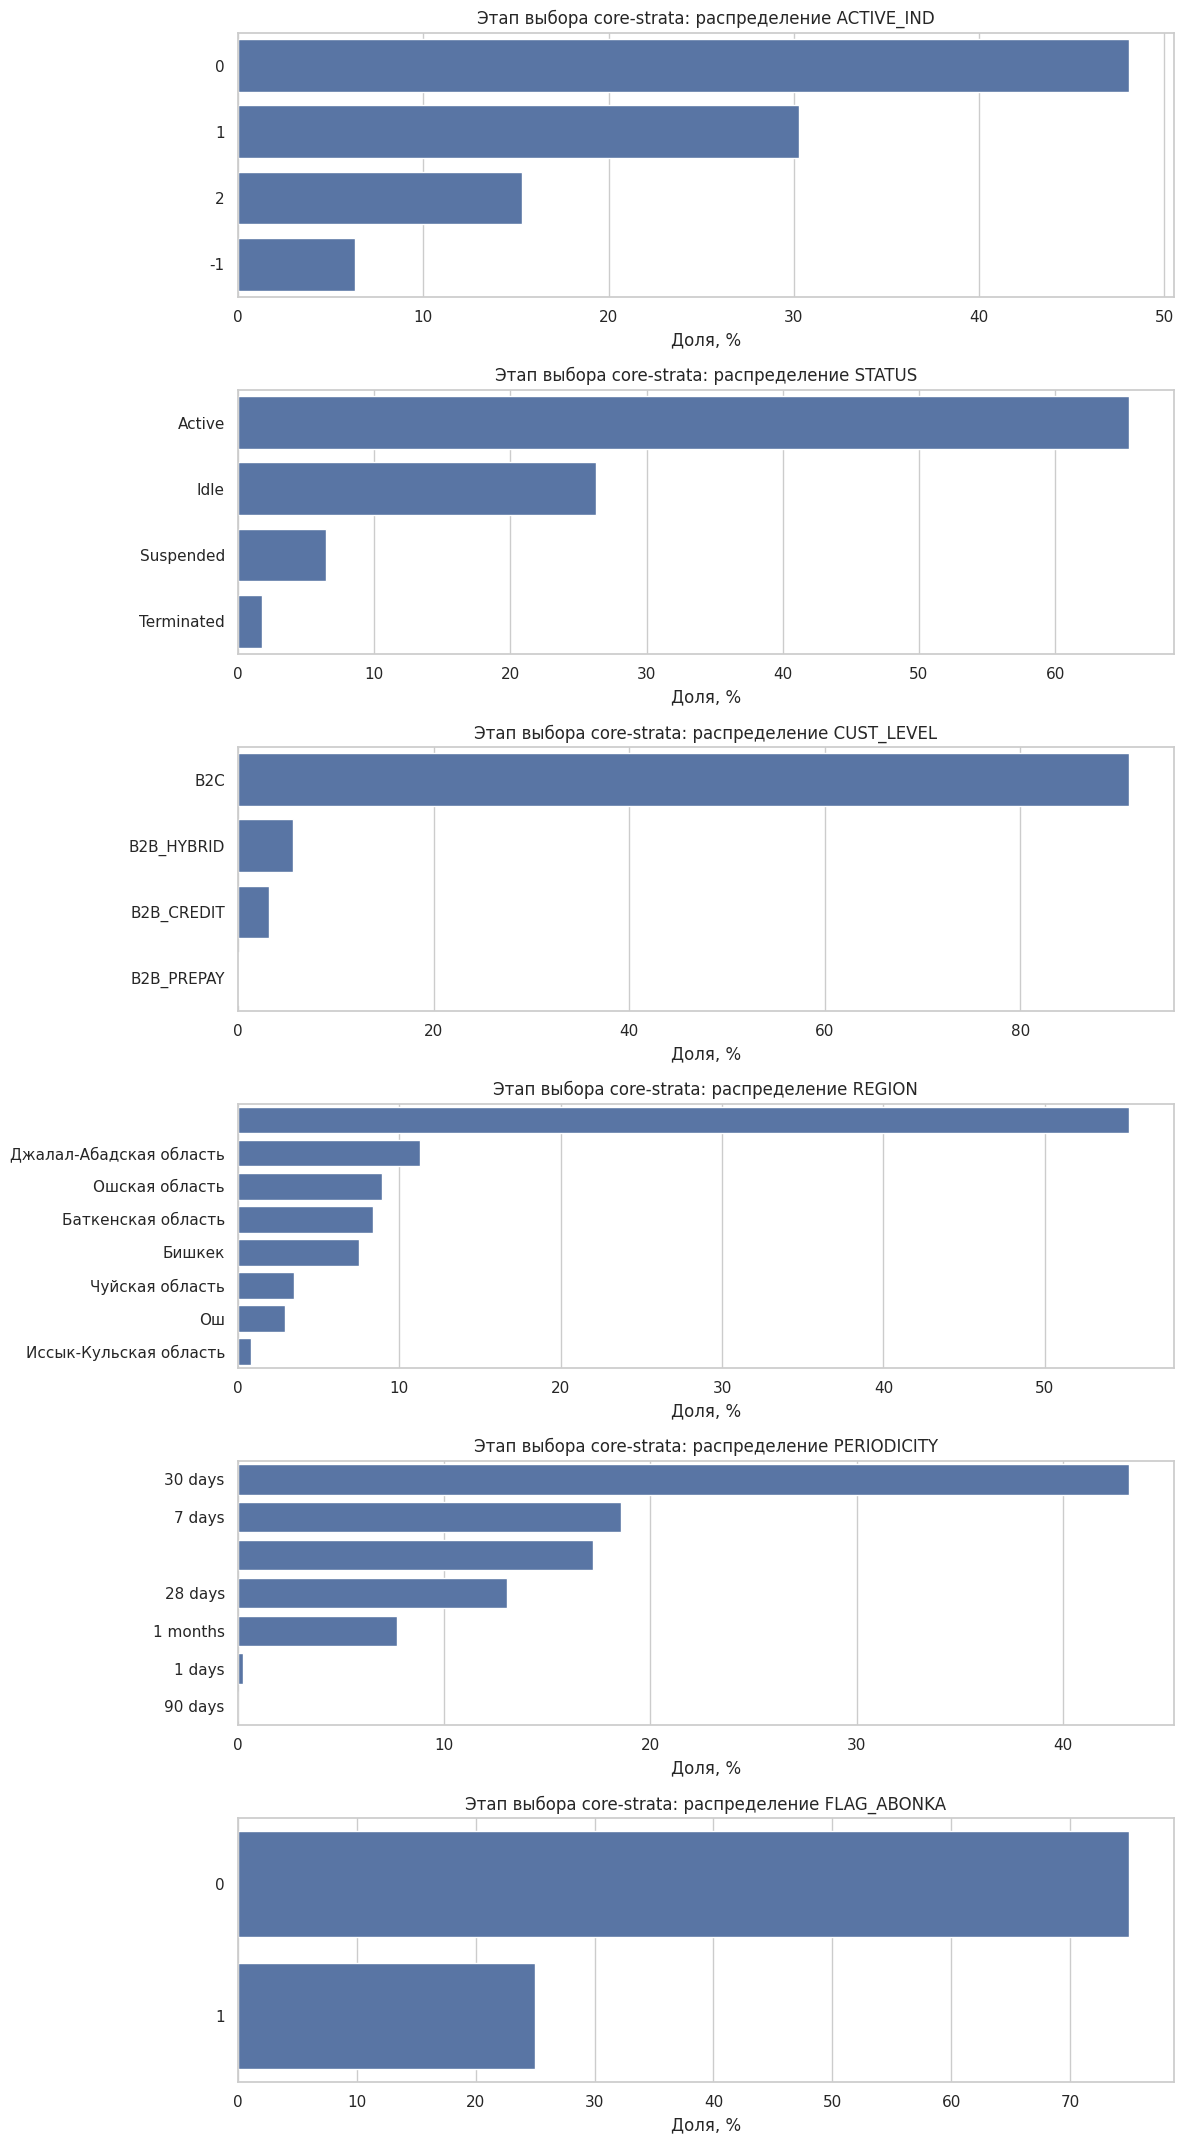

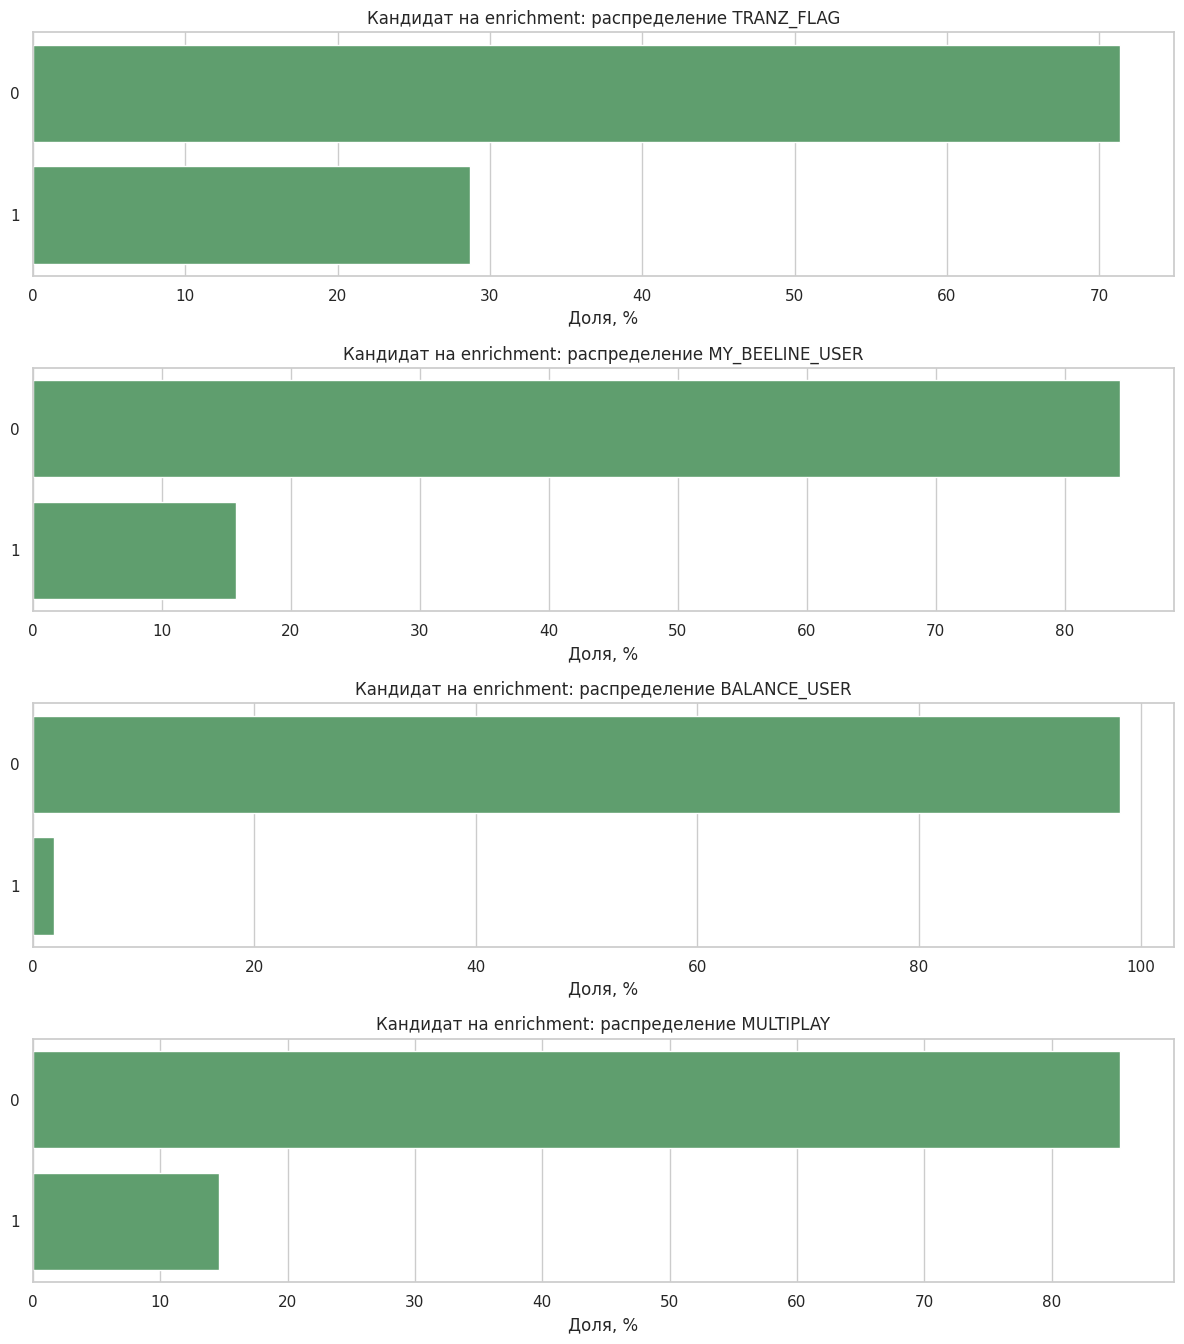

### Пример: плохой split против хорошего split

,Сценарий,Пример,Что_рискуем_получить
0,Плохой split,В test больше клиентов с высоким REVENUE_TOTAL...,"Завышенный uplift, который на самом деле объяс..."
1,Хороший split,"Control/test выровнены по статусу, региону, li...",Меньше смещения и более интерпретируемую оценк...


In [ ]:
demo_core_cols = [
    column
    for column in ["ACTIVE_IND", "CUST_LEVEL", "REGION", "PERIODICITY", "MY_BEELINE_USER", "ARPU_BUCKET"]
    if column in df.columns
][:6]

demo_candidate_cols = [
    column
    for column in ["TRANZ_FLAG", "BALANCE_USER", "MULTIPLAY", "FIRST_SIM"]
    if column in df.columns
][:4]

if demo_core_cols:
    fig, axes = plt.subplots(len(demo_core_cols), 1, figsize=(12, 3.6 * len(demo_core_cols)))
    if len(demo_core_cols) == 1:
        axes = [axes]

    for axis, column in zip(axes, demo_core_cols):
        shares = df[column].astype("string").fillna("MISSING").value_counts(normalize=True).head(8).mul(100)
        sns.barplot(x=shares.values, y=shares.index, color="#4C72B0", ax=axis)
        axis.set_title(f"Этап выбора core-strata: распределение {column}")
        axis.set_xlabel("Доля, %")
        axis.set_ylabel("")
    plt.tight_layout()
    plt.show()

if demo_candidate_cols:
    fig, axes = plt.subplots(len(demo_candidate_cols), 1, figsize=(12, 3.4 * len(demo_candidate_cols)))
    if len(demo_candidate_cols) == 1:
        axes = [axes]

    for axis, column in zip(axes, demo_candidate_cols):
        shares = df[column].astype("string").fillna("MISSING").value_counts(normalize=True).head(8).mul(100)
        sns.barplot(x=shares.values, y=shares.index, color="#55A868", ax=axis)
        axis.set_title(f"Кандидат на enrichment: распределение {column}")
        axis.set_xlabel("Доля, %")
        axis.set_ylabel("")
    plt.tight_layout()
    plt.show()

example_split_comparison = pd.DataFrame(
    [
        {
            "Сценарий": "Плохой split",
            "Пример": "В test больше клиентов с высоким REVENUE_TOTAL_INTERCONNECT и тяжелым usage-профилем.",
            "Что_рискуем_получить": "Завышенный uplift, который на самом деле объясняется baseline-разницей, а не кампанией.",
        },
        {
            "Сценарий": "Хороший split",
            "Пример": "Control/test выровнены по региону, lifecycle, monetization bucket и traffic bucket, а raw numeric-поля проверены KS.",
            "Что_рискуем_получить": "Меньше смещения и более интерпретируемую оценку causal effect.",
        },
    ]
)

display(Markdown("### Пример: плохой split против хорошего split"))
display(example_split_comparison)

In [11]:
split_policy = pd.DataFrame(
    [
        ("SUBS_ID", "id", "Ключ абонента", "exclude"),
        ("CTN", "id_like", "Номер абонента", "exclude"),
        ("IMEI", "id_like", "Imei девайса", "exclude"),
        ("ACTIVE_IND", "binary", "Индикатор активности", "stratify"),
        ("STATUS", "categorical", "Статус абонента: использовать как campaign filter, но не как mandatory-core", "exclude"),
        ("CUST_LEVEL", "categorical", "Тип клиента", "stratify"),
        ("REGION", "categorical", "Регион", "stratify"),
        ("PERIODICITY", "categorical", "Периодичность ТП", "stratify"),
        ("FLAG_4G", "binary", "Флаг SIM 4G", "stratify"),
        ("FLAG_ABONKA", "binary", "Абонент платил АП", "stratify"),
        ("TENURE_BUCKET", "bucket", "Сколько абонент с нами (LIFETIME_TOTAL)", "stratify"),
        ("ARPU_BUCKET", "bucket", "Корзина monetization на базе REVENUE_TOTAL_INTERCONNECT", "stratify"),
        ("TRAFFIC_BUCKET", "bucket", "Корзина data-usage на базе USAGE_INTERNET", "stratify"),
        ("MY_BEELINE_USER", "binary", "Пользователь My Beeline", "stratify"),
        ("PAYMENT_GAP_BUCKET", "bucket", "Исключен из ядра: monetization-баланс теперь задается через revenue bucket", "exclude"),
        ("TRANZ_FLAG", "binary", "Факт платного события в периоде", "candidate_stratify"),
        ("BALANCE_USER", "binary", "Пользователь balance.kg", "candidate_stratify"),
        ("MULTIPLAY", "binary", "Флаг цифровой / multiplay активности", "candidate_stratify"),
        ("FIRST_SIM", "binary", "Флаг первосимочника", "candidate_stratify"),
        ("REVENUE_TOTAL_INTERCONNECT", "numeric", "Совокупная выручка за период с учетом interconnect", "ks_check"),
        ("REVENUE_TOTAL", "numeric", "Общая сумма списаний с баланса включая корректировки", "ks_check"),
        ("TOTAL_RECHARGE", "numeric", "Сумма пополнений", "ks_check"),
        ("BALANCE_END", "numeric", "Баланс на конец периода", "ks_check"),
        ("USAGE_INTERNET", "numeric", "Общий интернет-трафик", "ks_check"),
        ("TOTAL_MOU", "numeric", "Сумма минут", "ks_check"),
        ("LIFETIME_TOTAL", "numeric", "Срок жизни абонента в сети", "ks_check"),
        ("DAYS_WITHOUT_PAYMENT", "numeric", "Дни без платных транзакций", "ks_check"),
    ],
    columns=["column", "type", "comment", "usage"],
)

strata_cols = [
    col for col in split_policy.loc[split_policy["usage"] == "stratify", "column"].tolist() if col in df.columns
]
candidate_strata_cols = [
    col for col in split_policy.loc[split_policy["usage"] == "candidate_stratify", "column"].tolist() if col in df.columns
]
ks_cols = [
    col for col in split_policy.loc[split_policy["usage"] == "ks_check", "column"].tolist()
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
]

selected_strata_cols = strata_cols.copy()
selected_split_version = "core_v4_interconnect_arpu_traffic_mybeeline"

display(split_policy)
display(Markdown(f"**Фактически используемые core-strata колонки:** {', '.join(strata_cols)}"))
display(Markdown(f"**Источник monetization для ARPU_BUCKET:** {MONETIZATION_COL}"))
display(Markdown(f"**Кандидаты на enrichment из EDA:** {', '.join(candidate_strata_cols) if candidate_strata_cols else 'нет'}"))
display(Markdown(f"**Фактически используемые KS-колонки:** {', '.join(ks_cols)}"))

print(f"Текущая рабочая версия split: {selected_split_version}")

,column,type,comment,usage
0,SUBS_ID,id,Ключ абонента,exclude
1,CTN,id_like,Номер абонента,exclude
2,IMEI,id_like,Imei девайса,exclude
3,ACTIVE_IND,binary,Индикатор активности,stratify
4,STATUS,categorical,Статус абонента: использовать как campaign fil...,exclude
5,CUST_LEVEL,categorical,Тип клиента,stratify
6,REGION,categorical,Регион,stratify
7,PERIODICITY,categorical,Периодичность ТП,stratify
8,FLAG_4G,binary,Флаг SIM 4G,stratify
9,FLAG_ABONKA,binary,Абонент платил АП,stratify


**Фактически используемые core-strata колонки:** ACTIVE_IND, CUST_LEVEL, REGION, PERIODICITY, FLAG_4G, FLAG_ABONKA, TENURE_BUCKET, ARPU_BUCKET, TRAFFIC_BUCKET, MY_BEELINE_USER

**Источник monetization для ARPU_BUCKET:** REVENUE_TOTAL_INTERCONNECT

**Кандидаты на enrichment из EDA:** TRANZ_FLAG, BALANCE_USER, MULTIPLAY, FIRST_SIM

**Фактически используемые KS-колонки:** REVENUE_TOTAL_INTERCONNECT, REVENUE_TOTAL, TOTAL_RECHARGE, BALANCE_END, USAGE_INTERNET, TOTAL_MOU, LIFETIME_TOTAL, DAYS_WITHOUT_PAYMENT

Текущая рабочая версия split: core_v4_interconnect_arpu_traffic_mybeeline


## Проверка enrichment-кандидата: стоит ли включать его в split

Этот раздел нужен как учебный пример того, почему не каждое полезное поле нужно автоматически добавлять в mandatory-core.

### Теория

После базового проектирования ядра almost всегда возникает соблазн добавить еще несколько "хороших" признаков. Обычно аргумент звучит так:
если поле важно для бизнеса, значит его нужно включить в strata.

Но это не всегда верно.

Каждое новое поле в ядре split дает два противоположных эффекта:
- потенциально улучшает baseline-balance;
- одновременно увеличивает число strata и риск появления маленьких ячеек.

Если маленьких strata становится слишком много, то при control share = 10% часть ячеек получает 0 или 1 клиента в control. Это означает, что дизайн формально стал богаче, но practically стал менее устойчивым.

Поэтому проверка enrichment-кандидатов отвечает на вопрос не только "полезно ли поле бизнесу", но и на вопрос "можно ли добавить его без потери устойчивости split".

### Пример

В текущем ноутбуке базовое ядро уже включает:
- lifecycle через `TENURE_BUCKET`;
- monetization через `ARPU_BUCKET`;
- traffic через `TRAFFIC_BUCKET`;
- коммуникационный канал через `MY_BEELINE_USER`.

После этого естественно проверить дополнительные признаки-кандидаты, например `TRANZ_FLAG`, `BALANCE_USER`, `MULTIPLAY`, `FIRST_SIM`.

Что мы делаем practically:
- считаем, сколько strata получается после добавления каждого кандидата;
- смотрим медианный размер strata;
- оцениваем долю всей базы, которая попадает в маленькие ячейки;
- превращаем эти метрики в рекомендацию: `скорее да`, `погранично` или `скорее нет`.

Например, если после добавления признака число strata резко растет, а медианный размер ячейки падает, то такой признак лучше оставить:
- либо кандидатом для отдельного теста;
- либо campaign filter;
- либо post-split monitoring полем.

### Вывод

Проверка enrichment-кандидатов нужна не для того, чтобы доказать, что поле "плохое".

Ее цель другая:
- показать цену добавления нового измерения в ядро split;
- отделить business importance от production suitability;
- оставить mandatory-core компактным и устойчивым.

Главный практический вывод:
поле должно попадать в обязательное ядро только тогда, когда выигрыш в baseline-balance действительно оправдывает рост fragmentation. Если этого нет, поле лучше использовать после split, а не внутри него.

### Сравнение дизайна strata: baseline vs текущая рабочая версия

Эта таблица нужна для учебной логики: она показывает, насколько усложнилось пространство strata после изменения ядра split.

,design,n_strata,mean_strata_size,median_strata_size,p10_strata_size,p90_strata_size,strata_lt_5,strata_lt_10,strata_lt_50,largest_stratum
0,core_v1,17848,163.68036,5.00000,1.00000,129.00000,8382,10752,14618,203323
1,core_v3_arpu_traffic_mybeeline,17848,163.68036,5.00000,1.00000,129.00000,8382,10752,14618,203323


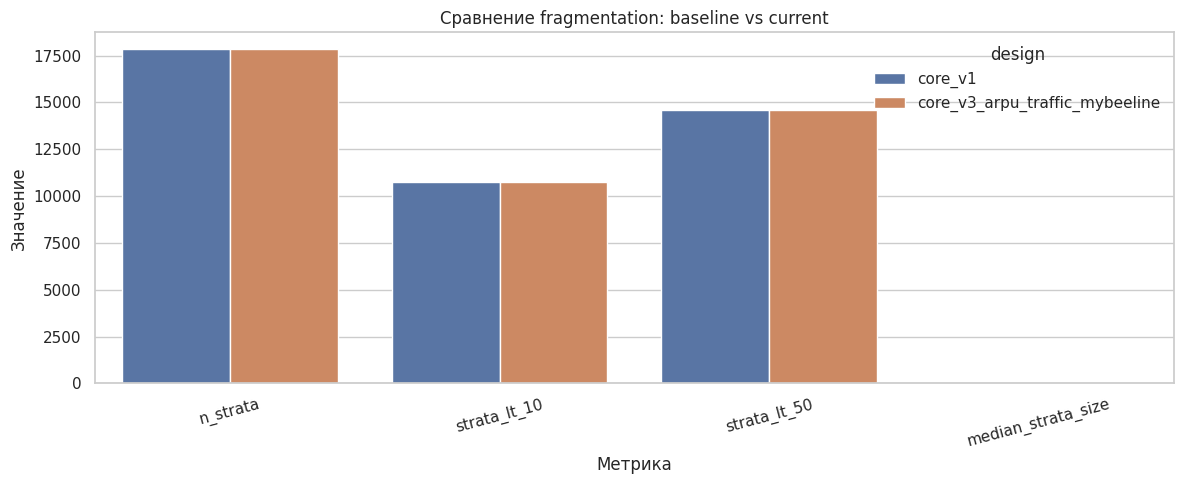

Учебный вывод: добавление новых полей в core полезно только тогда, когда выигрыш в baseline-balance не приводит к чрезмерному росту числа маленьких strata.


In [6]:
def build_strata_key(df: pd.DataFrame, columns: list[str]) -> pd.Series:
    """
    Собирает строковый ключ strata из набора колонок.

    Зачем это нужно:
    - split работает не по каждой колонке отдельно, а по комбинации baseline-признаков;
    - strata_key удобно использовать для подсчета емкости ячеек и самого assignment;
    - строковый ключ делает диагностику читаемой: можно увидеть, какие именно сочетания признаков формируют группу.
    """
    if not columns:
        return pd.Series("ALL", index=df.index)
    prepared = df[columns].copy()
    for column in columns:
        prepared[column] = prepared[column].astype("string").fillna("MISSING")
    return prepared.agg("|".join, axis=1)



def summarize_strata_design(df: pd.DataFrame, columns: list[str], design_name: str) -> dict:
    """
    Возвращает компактную сводку по тому, насколько дробится база при выбранном strata-дизайне.

    Почему эта функция важна для учебного материала:
    - она показывает цену добавления новых признаков в ядро split;
    - по ней видно не только число strata, но и типичный размер ячеек;
    - именно такие метрики помогают отличать красивую идею от production-устойчивого решения.
    """
    strata_key = build_strata_key(df, columns)
    counts = strata_key.value_counts()
    return {
        "design": design_name,
        "n_strata": int(counts.shape[0]),
        "mean_strata_size": float(counts.mean()),
        "median_strata_size": float(counts.median()),
        "p10_strata_size": float(counts.quantile(0.10)),
        "p90_strata_size": float(counts.quantile(0.90)),
        "strata_lt_5": int((counts < 5).sum()),
        "strata_lt_10": int((counts < 10).sum()),
        "strata_lt_50": int((counts < 50).sum()),
        "largest_stratum": int(counts.max()),
    }


core_design_summary = summarize_strata_design(df, strata_cols, "core_v1")
enriched_design_summary = summarize_strata_design(df, selected_strata_cols, selected_split_version)
design_comparison = pd.DataFrame([core_design_summary, enriched_design_summary])

display(Markdown("### Сравнение дизайна strata: baseline vs текущая рабочая версия"))
display(Markdown("Эта таблица нужна для учебной логики: она показывает, насколько усложнилось пространство strata после изменения ядра split."))
display(design_comparison)

comparison_plot = design_comparison.melt(
    id_vars="design",
    value_vars=["n_strata", "strata_lt_10", "strata_lt_50", "median_strata_size"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=comparison_plot, x="metric", y="value", hue="design")
plt.title("Сравнение fragmentation: baseline vs current")
plt.xlabel("Метрика")
plt.ylabel("Значение")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Учебный вывод: добавление новых полей в core полезно только тогда, когда выигрыш в baseline-balance не приводит к чрезмерному росту числа маленьких strata.")

## Отдельная проверка candidate-признаков для strata

Здесь мы отдельно отвечаем на практический вопрос:
- что будет, если добавить в `stratify` один из признаков `MY_BEELINE_USER`, `BALANCE_USER`, `MULTIPLAY`, `FIRST_SIM`;
- сколько получится strata;
- достаточно ли в этих strata наблюдений для control-share = 10%.

Как читаем результат:
- если strata слишком много, split становится хрупким;
- если слишком много strata с маленьким размером, в них будет 0 или 1 клиент в control, что плохо для устойчивости;
- особенно важно смотреть не только на количество маленьких strata, но и на долю **клиентов**, попадающих в такие strata.

### Сколько strata получается при добавлении candidate-признаков

Здесь важно читать не только число групп, но и то, какой процент всей базы попадает в слишком маленькие strata.

,design,n_features_in_strata,n_strata,median_strata_size,p10_strata_size,p90_strata_size,strata_lt_10,strata_lt_50,rows_share_lt_5_pct,rows_share_lt_10_pct,rows_share_lt_20_pct,rows_share_lt_50_pct,recommendation
0,current_core,10,17848,5.00000,1.00000,129.00000,10752,14618,0.51938,1.06080,1.92773,4.11311,Скорее нет: слишком много маленьких strata для...
1,core_plus_TRANZ_FLAG,11,17848,5.00000,1.00000,129.00000,10752,14618,0.51938,1.06080,1.92773,4.11311,Скорее нет: слишком много маленьких strata для...
2,core_plus_BALANCE_USER,11,23457,4.00000,1.00000,86.40000,15436,20068,0.75506,1.43625,2.50205,5.04736,Скорее нет: слишком много маленьких strata для...
3,core_plus_MULTIPLAY,11,22602,4.00000,1.00000,90.00000,14725,19272,0.72202,1.37614,2.43129,4.90507,Скорее нет: слишком много маленьких strata для...
4,core_plus_FIRST_SIM,11,26034,4.00000,1.00000,83.00000,16877,22329,0.81914,1.61575,2.92226,5.80266,Скорее нет: слишком много маленьких strata для...
5,core_plus_all_candidates,14,37370,3.00000,1.00000,51.00000,26888,33541,1.31065,2.36916,4.01610,7.35334,Скорее нет: слишком много маленьких strata для...


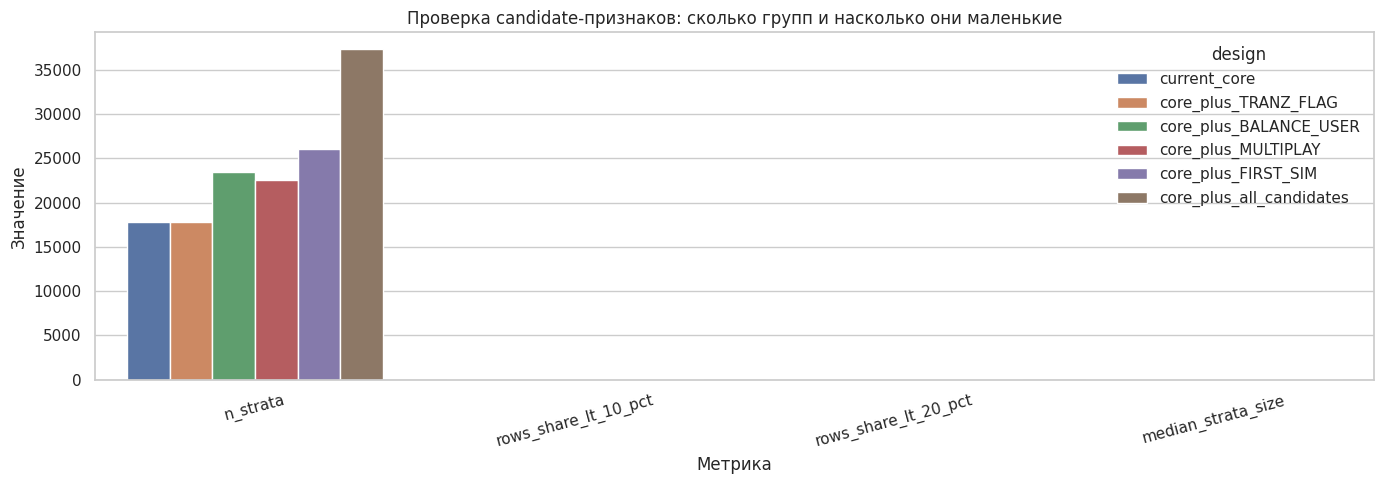

### Краткий вывод по каждому candidate-признаку

,design,n_strata,median_strata_size,rows_share_lt_10_pct,rows_share_lt_20_pct,recommendation
0,current_core,17848,5.00000,1.06080,1.92773,Скорее нет: слишком много маленьких strata для...
1,core_plus_TRANZ_FLAG,17848,5.00000,1.06080,1.92773,Скорее нет: слишком много маленьких strata для...
2,core_plus_BALANCE_USER,23457,4.00000,1.43625,2.50205,Скорее нет: слишком много маленьких strata для...
3,core_plus_MULTIPLAY,22602,4.00000,1.37614,2.43129,Скорее нет: слишком много маленьких strata для...
4,core_plus_FIRST_SIM,26034,4.00000,1.61575,2.92226,Скорее нет: слишком много маленьких strata для...
5,core_plus_all_candidates,37370,3.00000,2.36916,4.01610,Скорее нет: слишком много маленьких strata для...


Учебный вывод: если после добавления признака резко растет доля клиентов в маленьких strata, такой признак лучше оставить кандидатом или фильтром, а не частью обязательного ядра.


In [7]:
def summarize_strata_design_extended(df: pd.DataFrame, columns: list[str], design_name: str) -> dict:
    """
    Считает расширенную диагностику strata-дизайна, включая долю клиентов в маленьких ячейках.

    Почему простого числа strata недостаточно:
    - можно получить много strata, но почти все клиенты будут сидеть в крупных группах;
    - а можно получить умеренное число strata, но большая часть клиентов окажется в слишком маленьких ячейках;
    - для control share = 10% именно доля строк в маленьких strata особенно критична.
    """
    strata_key = build_strata_key(df, columns)
    counts = strata_key.value_counts()
    total_rows = float(counts.sum())

    rows_in_lt5 = float(counts[counts < 5].sum())
    rows_in_lt10 = float(counts[counts < 10].sum())
    rows_in_lt20 = float(counts[counts < 20].sum())
    rows_in_lt50 = float(counts[counts < 50].sum())

    return {
        "design": design_name,
        "n_features_in_strata": len(columns),
        "n_strata": int(counts.shape[0]),
        "median_strata_size": float(counts.median()),
        "p10_strata_size": float(counts.quantile(0.10)),
        "p90_strata_size": float(counts.quantile(0.90)),
        "strata_lt_10": int((counts < 10).sum()),
        "strata_lt_50": int((counts < 50).sum()),
        "rows_share_lt_5_pct": rows_in_lt5 / total_rows * 100,
        "rows_share_lt_10_pct": rows_in_lt10 / total_rows * 100,
        "rows_share_lt_20_pct": rows_in_lt20 / total_rows * 100,
        "rows_share_lt_50_pct": rows_in_lt50 / total_rows * 100,
    }



def evaluate_design_rule(row: pd.Series) -> str:
    """
    Переводит numeric-диагностику strata в простую бизнес-рекомендацию.

    Зачем это нужно:
    - не все читатели ноутбука будут интерпретировать fragmentation-метрики одинаково;
    - функция превращает технические пороги в понятную рекомендацию;
    - это удобно для обсуждения с бизнесом и для сравнения нескольких конфигураций ядра.
    """
    if row["rows_share_lt_10_pct"] > 10 or row["median_strata_size"] < 10:
        return "Скорее нет: слишком много маленьких strata для control=10%."
    if row["rows_share_lt_20_pct"] > 15:
        return "Погранично: можно тестировать, но есть риск фрагментации."
    return "Скорее да: объем strata выглядит приемлемым."


candidate_check_cols = [
    column
    for column in ["TRANZ_FLAG", "BALANCE_USER", "MULTIPLAY", "FIRST_SIM"]
    if column in df.columns
]

design_rows = [summarize_strata_design_extended(df, strata_cols, "current_core")]
for column in candidate_check_cols:
    design_rows.append(
        summarize_strata_design_extended(df, strata_cols + [column], f"core_plus_{column}")
    )

if candidate_check_cols:
    design_rows.append(
        summarize_strata_design_extended(df, strata_cols + candidate_check_cols, "core_plus_all_candidates")
    )

candidate_strata_check = pd.DataFrame(design_rows)
candidate_strata_check["recommendation"] = candidate_strata_check.apply(evaluate_design_rule, axis=1)

display(Markdown("### Сколько strata получается при добавлении candidate-признаков"))
display(Markdown("Здесь важно читать не только число групп, но и то, какой процент всей базы попадает в слишком маленькие strata."))
display(candidate_strata_check)

plot_candidate_check = candidate_strata_check.melt(
    id_vars="design",
    value_vars=["n_strata", "rows_share_lt_10_pct", "rows_share_lt_20_pct", "median_strata_size"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(14, 5))
sns.barplot(data=plot_candidate_check, x="metric", y="value", hue="design")
plt.title("Проверка candidate-признаков: сколько групп и насколько они маленькие")
plt.xlabel("Метрика")
plt.ylabel("Значение")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

candidate_takeaway = candidate_strata_check[["design", "n_strata", "median_strata_size", "rows_share_lt_10_pct", "rows_share_lt_20_pct", "recommendation"]]
display(Markdown("### Краткий вывод по каждому candidate-признаку"))
display(candidate_takeaway)

print("Учебный вывод: если после добавления признака резко растет доля клиентов в маленьких strata, такой признак лучше оставить кандидатом или фильтром, а не частью обязательного ядра.")

## Ответ на письмо: обязательные параметры выравнивания и логика жизни УКГ

Ниже фиксируем практическое решение, которое можно отправлять бизнес-заказчику как рабочую методологию.

### 1. Какие параметры обязательны для выравнивания в universal control group

В `core-strata` оставляем только признаки, которые одновременно:
- критичны для baseline-сопоставимости;
- устойчивы до воздействия;
- имеют умеренную кардинальность;
- не дробят базу до слишком маленьких strata.

В текущем дизайне обязательные признаки для выравнивания такие:
- `ACTIVE_IND`;
- `STATUS`;
- `CUST_LEVEL`;
- `REGION`;
- `PERIODICITY`;
- `FLAG_4G`;
- `FLAG_ABONKA`;
- `TENURE_BUCKET`;
- `PAYMENT_GAP_BUCKET`.

### 2. Какие признаки не надо включать в обязательное выравнивание

Следующие признаки полезны, но их лучше не включать в обязательный monthly split по всей базе, потому что они резко увеличивают число маленьких групп:
- `MY_BEELINE_USER`;
- `BALANCE_USER`;
- `MULTIPLAY`;
- `FIRST_SIM`.

`TRANZ_FLAG` можно рассматривать только как controlled enrichment-кандидат, а не как обязательное поле по умолчанию.

### 3. Как использовать дополнительные признаки в маркетинговом анализе

Логика должна быть такой:
- сначала строим один глобальный UKG по компактному `core-strata`;
- затем для конкретной кампании берем не всю `test`-группу, а только релевантный срез клиентов;
- например, для churn-анализов работаем только с активными, для reactivate — только с неактивными.

То есть campaign-specific сегментация должна происходить **после** глобального split, а не за счет бесконечного расширения числа strata.

### 4. Логика жизни УКГ

Подтверждаем следующую логику:
- абонент, попавший в УКГ, остается в ней постоянно;
- ежемесячно добавляем только новых клиентов отчетного месяца;
- существующих участников УКГ не перераспределяем заново;
- для production это означает хранение persistent assignment table по `SUBS_ID` с признаком первой даты включения и версией методологии.

### 5. Что еще нужно формально зафиксировать с бизнесом

Письма достаточно как бизнес-рамки, но для production еще нужно зафиксировать:
- точный источник исключений (`employees`, `test numbers`, `M2M`);
- считается ли абонент членом УКГ навсегда даже при временном уходе из базы и последующем возврате;
- какие campaign-specific фильтры обязательны для каждого сценария (`churn`, `reactivate`, upsell и т.д.).

In [12]:
core_mandatory_cols = [
    column
    for column in [
        "ACTIVE_IND",
        "CUST_LEVEL",
        "REGION",
        "PERIODICITY",
        "FLAG_4G",
        "FLAG_ABONKA",
        "TENURE_BUCKET",
        "ARPU_BUCKET",
        "TRAFFIC_BUCKET",
        "MY_BEELINE_USER",
    ]
    if column in df.columns
]

enrichment_candidate_cols = [
    column
    for column in ["TRANZ_FLAG", "BALANCE_USER", "MULTIPLAY", "FIRST_SIM"]
    if column in df.columns
]

analysis_filter_cols = [
    column
    for column in ["ACTIVE_IND", "STATUS", "CUST_LEVEL", "MY_BEELINE_USER"]
    if column in df.columns
]

monitor_numeric_cols = [
    column
    for column in [
        "REVENUE_TOTAL_INTERCONNECT",
        "REVENUE_TOTAL",
        "TOTAL_RECHARGE",
        "BALANCE_END",
        "USAGE_INTERNET",
        "TOTAL_MOU",
        "LIFETIME_TOTAL",
        "DAYS_WITHOUT_PAYMENT",
    ]
    if column in df.columns
]

def collect_design_summary(df: pd.DataFrame, columns: list[str], design_name: str) -> dict:
    """
    Собирает сводку по дизайну strata для таблиц сравнения и бизнес-экспорта.

    Зачем это нужно:
    - в одном месте считаются и теоретическая емкость комбинаций, и фактически наблюдаемые strata;
    - функция делает сопоставимыми разные версии ядра split;
    - именно эта сводка потом попадает в Excel, который читает бизнес.
    """
    prepared = df[columns].copy() if columns else pd.DataFrame(index=df.index)
    unique_counts = {}
    for column in columns:
        prepared[column] = prepared[column].astype("string").fillna("MISSING")
        unique_counts[column] = int(prepared[column].nunique())

    theoretical_max = int(np.prod(list(unique_counts.values()))) if unique_counts else 1
    fragmentation = summarize_strata_design_extended(df, columns, design_name)
    return {
        "design": design_name,
        "columns": ", ".join(columns),
        "n_columns": len(columns),
        "theoretical_max_groups": theoretical_max,
        "observed_strata_in_slice": int(build_strata_key(df, columns).nunique()),
        "median_strata_size": fragmentation["median_strata_size"],
        "rows_share_lt_10_pct": fragmentation["rows_share_lt_10_pct"],
        "rows_share_lt_20_pct": fragmentation["rows_share_lt_20_pct"],
    }


def interpret_capacity(summary: dict, baseline: dict | None = None) -> str:
    """
    Превращает сводку по strata в короткую управленческую рекомендацию.

    Почему это важно:
    - бизнесу неудобно принимать решение по голым метрикам fragmentation;
    - функция фиксирует единые пороги оценки и делает выводы воспроизводимыми;
    - так обсуждение идет не на уровне ощущений, а на уровне формализованного правила.
    """
    if baseline is None:
        return "Рабочий baseline: core-ядро уже валидировано SRM/KS и подходит для monthly UKG."
    if summary["median_strata_size"] < 5 or summary["rows_share_lt_10_pct"] >= 0.50:
        return "Нет: фрагментация слишком высокая, в mandatory-core включать не стоит."
    if (
        summary["observed_strata_in_slice"] > baseline["observed_strata_in_slice"] * 1.15
        or summary["rows_share_lt_10_pct"] > baseline["rows_share_lt_10_pct"] + 0.03
    ):
        return "Погранично: можно тестировать отдельно, но не делать обязательным полем по умолчанию."
    return "Допустимо как optional enrichment после повторной SRM/KS-проверки."

core_summary = collect_design_summary(df, core_mandatory_cols, "core_mandatory")
tranz_summary = collect_design_summary(
    df,
    core_mandatory_cols + (["TRANZ_FLAG"] if "TRANZ_FLAG" in df.columns else []),
    "core_plus_TRANZ_FLAG",
)
all_candidates_summary = collect_design_summary(
    df,
    core_mandatory_cols + [
        column
        for column in ["TRANZ_FLAG", "BALANCE_USER", "MULTIPLAY", "FIRST_SIM"]
        if column in df.columns
    ],
    "core_plus_all_candidates",
)

group_capacity_summary = pd.DataFrame([core_summary, tranz_summary, all_candidates_summary])
group_capacity_summary["recommendation"] = [
    interpret_capacity(core_summary),
    interpret_capacity(tranz_summary, baseline=core_summary),
    interpret_capacity(all_candidates_summary, baseline=core_summary),
]

parameter_role_decision = pd.DataFrame(
    [
        {
            "role": "mandatory_balance",
            "columns": ", ".join(core_mandatory_cols),
            "why": "Ядро monthly split с учетом структуры базы, monetization, usage и канала коммуникации.",
            "how_to_use": "Включать в ежемесячный persistent UKG assignment.",
        },
        {
            "role": "campaign_filter_only",
            "columns": ", ".join(analysis_filter_cols),
            "why": "Эти признаки могут использоваться для отбора нужного поднабора test/control под конкретную задачу, даже если часть из них уже включена в core.",
            "how_to_use": "После split фильтровать нужные сегменты кампании по активности, статусу, customer level и каналу.",
        },
        {
            "role": "optional_enrichment_candidate",
            "columns": ", ".join(enrichment_candidate_cols),
            "why": "Полезны бизнес-смыслово, но не все подходят в обязательное strata из-за роста числа маленьких групп.",
            "how_to_use": "Тестировать отдельно и включать только после fragmentation-check.",
        },
        {
            "role": "monitor_only_numeric",
            "columns": ", ".join(monitor_numeric_cols),
            "why": "Raw непрерывные поля полезны для KS и post-split контроля, даже если часть их сигналов уже представлена через bucket-признаки.",
            "how_to_use": "Использовать в balance report и campaign evaluation.",
        },
    ]
)

ukg_lifecycle_rules = pd.DataFrame(
    [
        {
            "rule": "membership_persistent",
            "decision": "Да",
            "implementation": "Если SUBS_ID однажды попал в control, он остается в UKG в следующих месяцах.",
        },
        {
            "rule": "monthly_additions_only_new_clients",
            "decision": "Да",
            "implementation": "Ежемесячно добавляем только новых eligible клиентов, которых еще нет в assignment table.",
        },
        {
            "rule": "monthly_reassignment",
            "decision": "Нет",
            "implementation": "Существующих клиентов не перераспределяем заново, даже если их признаки изменились.",
        },
        {
            "rule": "campaign_analysis_on_filtered_subset",
            "decision": "Да",
            "implementation": "Для churn/reactivate/upsell берем не всю test группу, а нужный аналитический срез после global split.",
        },
    ]
)

open_questions_for_business = pd.DataFrame(
    [
        {
            "topic": "Exclusion source",
            "question": "Из какой витрины и по каким правилам исключаем employees, test numbers и M2M?",
        },
        {
            "topic": "Returning subscriber",
            "question": "Если абонент вышел из eligible-базы, а потом вернулся, сохраняем ли старое membership без изменений?",
        },
        {
            "topic": "Channel logic",
            "question": "Если MY_BEELINE_USER включен в core, нужны ли еще отдельные правила для каналов SMS, app push и IVR?",
        },
    ]
)

display(Markdown("### Какие параметры обязательны, а какие нет"))
display(Markdown("Это ключевая учебная таблица: она разделяет роли полей между ядром split, фильтрами кампаний, кандидатами на обогащение и post-split мониторингом."))
display(parameter_role_decision)

display(Markdown("### Сколько групп это потенциально дает"))
display(group_capacity_summary)

display(Markdown("### Подтвержденная логика жизни УКГ"))
display(ukg_lifecycle_rules)

display(Markdown("### Что еще нужно дозафиксировать с бизнесом"))
display(open_questions_for_business)

core_fields_text = ", ".join(core_mandatory_cols)
print(f"Рекомендуемое обязательное ядро strata: {core_fields_text}")
print(f"Для monetization-оси в текущей версии используется источник: {MONETIZATION_COL}")
print("Практический принцип: campaign-specific признаки лучше использовать как фильтр анализа после split, а непрерывные monetization и usage-сигналы включать в ядро только через bucket-признаки.")

### Какие параметры обязательны, а какие нет

Это ключевая учебная таблица: она разделяет роли полей между ядром split, фильтрами кампаний, кандидатами на обогащение и post-split мониторингом.

,role,columns,why,how_to_use
0,mandatory_balance,"ACTIVE_IND, CUST_LEVEL, REGION, PERIODICITY, F...","Ядро monthly split с учетом структуры базы, mo...",Включать в ежемесячный persistent UKG assignment.
1,campaign_filter_only,"ACTIVE_IND, STATUS, CUST_LEVEL, MY_BEELINE_USER",Эти признаки могут использоваться для отбора н...,После split фильтровать нужные сегменты кампан...
2,optional_enrichment_candidate,"TRANZ_FLAG, BALANCE_USER, MULTIPLAY, FIRST_SIM","Полезны бизнес-смыслово, но не все подходят в ...",Тестировать отдельно и включать только после f...
3,monitor_only_numeric,"REVENUE_TOTAL_INTERCONNECT, REVENUE_TOTAL, TOT...",Raw непрерывные поля полезны для KS и post-spl...,Использовать в balance report и campaign evalu...


### Сколько групп это потенциально дает

,design,columns,n_columns,theoretical_max_groups,observed_strata_in_slice,median_strata_size,rows_share_lt_10_pct,rows_share_lt_20_pct,recommendation
0,core_mandatory,"ACTIVE_IND, CUST_LEVEL, REGION, PERIODICITY, F...",10,2069760,22409,5.00000,1.37549,2.56332,Рабочий baseline: core-ядро уже валидировано S...
1,core_plus_TRANZ_FLAG,"ACTIVE_IND, CUST_LEVEL, REGION, PERIODICITY, F...",11,4139520,23513,5.00000,1.45541,2.66214,"Нет: фрагментация слишком высокая, в mandatory..."
2,core_plus_all_candidates,"ACTIVE_IND, CUST_LEVEL, REGION, PERIODICITY, F...",14,33116160,44977,3.00000,2.90124,4.91489,"Нет: фрагментация слишком высокая, в mandatory..."


### Подтвержденная логика жизни УКГ

,rule,decision,implementation
0,membership_persistent,Да,"Если SUBS_ID однажды попал в control, он остае..."
1,monthly_additions_only_new_clients,Да,Ежемесячно добавляем только новых eligible кли...
2,monthly_reassignment,Нет,Существующих клиентов не перераспределяем зано...
3,campaign_analysis_on_filtered_subset,Да,Для churn/reactivate/upsell берем не всю test ...


### Что еще нужно дозафиксировать с бизнесом

,topic,question
0,Exclusion source,Из какой витрины и по каким правилам исключаем...
1,Returning subscriber,"Если абонент вышел из eligible-базы, а потом в..."
2,Channel logic,"Если MY_BEELINE_USER включен в core, нужны ли ..."


Рекомендуемое обязательное ядро strata: ACTIVE_IND, CUST_LEVEL, REGION, PERIODICITY, FLAG_4G, FLAG_ABONKA, TENURE_BUCKET, ARPU_BUCKET, TRAFFIC_BUCKET, MY_BEELINE_USER
Для monetization-оси в текущей версии используется источник: REVENUE_TOTAL_INTERCONNECT
Практический принцип: campaign-specific признаки лучше использовать как фильтр анализа после split, а непрерывные monetization и usage-сигналы включать в ядро только через bucket-признаки.


## Если бизнесу важны другие поля: как принимать решение без раздувания strata

Да, бизнесу могут быть важны и другие поля. Но важность для бизнеса не означает, что поле автоматически должно войти в обязательное monthly stratification ядро.

Правило выбора такое:
- если поле критично почти для всех кампаний и описывает baseline клиента до воздействия, его можно рассматривать для `core-strata`;
- если поле важно только для части сценариев, его лучше использовать как `campaign_filter_only`;
- если поле непрерывное, его почти всегда лучше оставить в `ks_check` или monitoring;
- если добавление поля резко увеличивает число маленьких strata, его нельзя делать обязательным даже при хорошем бизнес-смысле.

Иначе мы получим методологически красивый список полей, но плохой production split.

In [19]:
business_priority_framework = pd.DataFrame(
    [
        {
            "field_group": "ACTIVE_IND, STATUS",
            "if_business_says": "Нужно разделять active / inactive или разные операционные статусы",
            "recommended_role": "mandatory_balance + campaign_filter",
            "why": "Это universal baseline-признаки, важные почти для любого сценария.",
            "decision_rule": "Оставляем в core-strata и дополнительно используем как фильтр под конкретную кампанию.",
        },
        {
            "field_group": "CUST_LEVEL",
            "if_business_says": "Важна разница между B2C/B2B или другими customer levels",
            "recommended_role": "mandatory_balance + campaign_filter",
            "why": "Признак влияет на экономику и поведение, поэтому должен быть выровнен глобально.",
            "decision_rule": "Оставляем в core-strata; при анализе кампании можно дополнительно ограничивать выборку нужным customer level.",
        },
        {
            "field_group": "REGION, PERIODICITY",
            "if_business_says": "Важно, чтобы контроль отражал географию и продуктовый профиль",
            "recommended_role": "mandatory_balance",
            "why": "Это универсальные структурные различия базы, которые лучше выравнивать заранее.",
            "decision_rule": "Оставляем в core-strata по умолчанию.",
        },
        {
            "field_group": "FLAG_4G, FLAG_ABONKA",
            "if_business_says": "Нужен баланс по технологической и платежной зрелости",
            "recommended_role": "mandatory_balance",
            "why": "Это компактные и сильные pre-treatment признаки.",
            "decision_rule": "Оставляем в core-strata по умолчанию.",
        },
        {
            "field_group": "TENURE_BUCKET, PAYMENT_GAP_BUCKET",
            "if_business_says": "Нужен баланс по lifecycle и churn-risk",
            "recommended_role": "mandatory_balance",
            "why": "Это поведенческие proxy вместо чувствительных демографических полей.",
            "decision_rule": "Оставляем в core-strata по умолчанию.",
        },
        {
            "field_group": "TRANZ_FLAG",
            "if_business_says": "Для большинства кампаний критичен сам факт недавнего платного события",
            "recommended_role": "optional_enrichment_candidate",
            "why": "Бизнес-смысл хороший, но добавление нужно подтверждать fragmentation-check и повторным SRM/KS.",
            "decision_rule": "Поднимать в strata только если это регулярное требование почти всех кампаний.",
        },
        {
            "field_group": "MY_BEELINE_USER, BALANCE_USER, MULTIPLAY, FIRST_SIM",
            "if_business_says": "Важна digital / ecosystem сегментация",
            "recommended_role": "campaign_filter_only",
            "why": "Эти поля лучше использовать как слой отбора или аналитики, чем как обязательные оси global split.",
            "decision_rule": "Не добавлять в mandatory-core без отдельного доказательства, что выгода выше потери устойчивости strata.",
        },
        {
            "field_group": "REVENUE_TOTAL, TOTAL_RECHARGE, BALANCE_END, USAGE_INTERNET, TOTAL_MOU, LIFETIME_TOTAL, DAYS_WITHOUT_PAYMENT",
            "if_business_says": "Нужен баланс по денежным и usage-метрикам",
            "recommended_role": "monitor_only_numeric",
            "why": "Это числовые поля; их лучше контролировать через KS и summary statistics, а не через прямую стратификацию.",
            "decision_rule": "Оставлять в post-split balance report и использовать в campaign evaluation.",
        },
    ]
)

promotion_rule = pd.DataFrame(
    [
        {
            "criterion": "Поле важно почти для всех кампаний",
            "meaning": "Это не локальный сценарный фильтр, а универсальный baseline-фактор.",
        },
        {
            "criterion": "Поле измерено до воздействия и стабильно между месяцами",
            "meaning": "Нет leakage и нет сильной месячной нестабильности.",
        },
        {
            "criterion": "Поле не взрывает количество strata",
            "meaning": "После добавления не появляется много маленьких групп и split остается воспроизводимым.",
        },
        {
            "criterion": "Поле улучшает balance больше, чем вредит fragmentation",
            "meaning": "Есть практический выигрыш по SRM/KS или по бизнес-интерпретации, а не только интуитивная полезность.",
        },
    ]
)

display(Markdown("### Как трактовать бизнес-важность признаков"))
display(business_priority_framework)

display(Markdown("### Когда поле можно переводить из candidate/filter в mandatory-core"))
display(promotion_rule)

print("Практический вывод: если бизнес говорит, что поле важно, сначала определяем его роль. Не каждое важное поле должно попадать в strata; часто правильнее использовать его как фильтр кампании или как post-split метрику контроля.")

### Как трактовать бизнес-важность признаков

,field_group,if_business_says,recommended_role,why,decision_rule
0,"ACTIVE_IND, STATUS",Нужно разделять active / inactive или разные о...,mandatory_balance + campaign_filter,"Это universal baseline-признаки, важные почти ...",Оставляем в core-strata и дополнительно исполь...
1,CUST_LEVEL,Важна разница между B2C/B2B или другими custom...,mandatory_balance + campaign_filter,"Признак влияет на экономику и поведение, поэто...",Оставляем в core-strata; при анализе кампании ...
2,"REGION, PERIODICITY","Важно, чтобы контроль отражал географию и прод...",mandatory_balance,"Это универсальные структурные различия базы, к...",Оставляем в core-strata по умолчанию.
3,"FLAG_4G, FLAG_ABONKA",Нужен баланс по технологической и платежной зр...,mandatory_balance,Это компактные и сильные pre-treatment признаки.,Оставляем в core-strata по умолчанию.
4,"TENURE_BUCKET, PAYMENT_GAP_BUCKET",Нужен баланс по lifecycle и churn-risk,mandatory_balance,Это поведенческие proxy вместо чувствительных ...,Оставляем в core-strata по умолчанию.
5,TRANZ_FLAG,Для большинства кампаний критичен сам факт нед...,optional_enrichment_candidate,"Бизнес-смысл хороший, но добавление нужно подт...",Поднимать в strata только если это регулярное ...
6,"MY_BEELINE_USER, BALANCE_USER, MULTIPLAY, FIRS...",Важна digital / ecosystem сегментация,campaign_filter_only,Эти поля лучше использовать как слой отбора ил...,Не добавлять в mandatory-core без отдельного д...
7,"REVENUE_TOTAL, TOTAL_RECHARGE, BALANCE_END, US...",Нужен баланс по денежным и usage-метрикам,monitor_only_numeric,Это числовые поля; их лучше контролировать чер...,Оставлять в post-split balance report и исполь...


### Когда поле можно переводить из candidate/filter в mandatory-core

,criterion,meaning
0,Поле важно почти для всех кампаний,"Это не локальный сценарный фильтр, а универсал..."
1,Поле измерено до воздействия и стабильно между...,Нет leakage и нет сильной месячной нестабильно...
2,Поле не взрывает количество strata,После добавления не появляется много маленьких...
3,"Поле улучшает balance больше, чем вредит fragm...",Есть практический выигрыш по SRM/KS или по биз...


Практический вывод: если бизнес говорит, что поле важно, сначала определяем его роль. Не каждое важное поле должно попадать в strata; часто правильнее использовать его как фильтр кампании или как post-split метрику контроля.


## Подробное обоснование по каждой колонке split-политики

В этом разделе фиксируется решение по каждой колонке:
- почему колонка включена или исключена;
- какую роль она играет (`stratify`, `ks_check`, `candidate_stratify`, `exclude`);
- какие риски есть у колонки;
- какие проверки нужно смотреть после split;
- какие признаки можно подключать в следующей версии split как controlled enrichment, не включая их сразу в production-ядро.

In [ ]:
column_rationale = {
    "SUBS_ID": {
        "business_reason": "Стабильный ключ абонента для детерминированного назначения.",
        "stat_reason": "Используется только для hash и воспроизводимости, не для стратификации.",
        "risk": "Если ключ меняется между витринами, нарушится стабильность назначения.",
        "decision_detail": "exclude_from_features_use_for_hash",
        "post_split_check": "Уникальность ключа и отсутствие дублей assignment.",
    },
    "CTN": {
        "business_reason": "Операционный идентификатор номера.",
        "stat_reason": "Очень высокая кардинальность, не подходит для strata.",
        "risk": "Почти-уникальные уровни создают шум и переобучение strata.",
        "decision_detail": "exclude_high_cardinality_id_like",
        "post_split_check": "Только контроль дублей и полноты поля.",
    },
    "IMEI": {
        "business_reason": "Идентификатор устройства.",
        "stat_reason": "ID-like поле с большой долей уникальных значений.",
        "risk": "Нестабильность устройства и высокая кардинальность.",
        "decision_detail": "exclude_high_cardinality_id_like",
        "post_split_check": "Не использовать как strata; мониторить пропуски.",
    },
    "ACTIVE_IND": {
        "business_reason": "Ключевой статус активности абонента.",
        "stat_reason": "Небольшое число уровней, хорошо работает в strata.",
        "risk": "Сильный дисбаланс классов возможен по периодам.",
        "decision_detail": "stratify_core_state",
        "post_split_check": "Сравнить доли уровней между control/test.",
    },
    "STATUS": {
        "business_reason": "Операционный статус полезен для сценарной аналитики.",
        "stat_reason": "В текущей версии не входит в mandatory-core и используется как campaign filter, чтобы не дублировать другие baseline-оси.",
        "risk": "Если вернуть в core без пересборки логики, strata могут раздуться без заметного выигрыша.",
        "decision_detail": "exclude_from_current_core_use_as_campaign_filter",
        "post_split_check": "При необходимости смотреть распределение статусов уже на аналитическом поднаборе кампании.",
    },
    "CUST_LEVEL": {
        "business_reason": "Сегментация клиента B2C/B2B и др.",
        "stat_reason": "Влияет на экономику и usage, нужен в strata.",
        "risk": "Редкие уровни могут быть нестабильны.",
        "decision_detail": "stratify_business_segment",
        "post_split_check": "Доли категорий и покрытие редких сегментов.",
    },
    "REGION": {
        "business_reason": "Географический профиль абонента.",
        "stat_reason": "Уменьшает региональный сдвиг между группами.",
        "risk": "Миграции/динамика региона между периодами.",
        "decision_detail": "stratify_geo",
        "post_split_check": "Доли регионов и максимальное отклонение.",
    },
    "PERIODICITY": {
        "business_reason": "Частота тарифа связана с платежным профилем.",
        "stat_reason": "Важный категориальный фактор для выравнивания.",
        "risk": "Изменение продуктовой матрицы со временем.",
        "decision_detail": "stratify_tariff_behavior",
        "post_split_check": "Доли weekly/monthly и др. по группам.",
    },
    "FLAG_4G": {
        "business_reason": "Технологический профиль SIM.",
        "stat_reason": "Бинарный признак с бизнес-смыслом, хорош для strata.",
        "risk": "Сильный перекос долей 1/0.",
        "decision_detail": "stratify_tech_profile",
        "post_split_check": "Баланс долей 4G/не-4G.",
    },
    "FLAG_ABONKA": {
        "business_reason": "Факт оплаты абонплаты.",
        "stat_reason": "Ключевой платежный маркер, улучшает сопоставимость.",
        "risk": "Сезонные изменения в оплатах.",
        "decision_detail": "stratify_payment_behavior",
        "post_split_check": "Доля плативших в обеих группах.",
    },
    "TENURE_BUCKET": {
        "business_reason": "Срок жизни в сети без использования возраста/пола.",
        "stat_reason": "Снижает сдвиг по жизненному циклу абонента.",
        "risk": "Пограничные эффекты из-за бинов.",
        "decision_detail": "stratify_lifecycle_bucket",
        "post_split_check": "Баланс по tenure-корзинам.",
    },
    "ARPU_BUCKET": {
        "business_reason": "Корзина monetization для выравнивания базы по более полной выручке абонента.",
        "stat_reason": "Позволяет добавить денежную ось в strata без использования raw непрерывного поля.",
        "risk": "Если bucket-логика будет слишком детальной, резко вырастет число strata.",
        "decision_detail": "stratify_monetization_bucket",
        "post_split_check": "Проверять raw REVENUE_TOTAL_INTERCONNECT через KS и summary statistics.",
    },
    "TRAFFIC_BUCKET": {
        "business_reason": "Корзина data-usage для выравнивания по трафиковому профилю.",
        "stat_reason": "Позволяет балансировать heavy/light usage без прямого включения raw USAGE_INTERNET.",
        "risk": "Слишком детальный binning может ухудшить fragmentation.",
        "decision_detail": "stratify_usage_bucket",
        "post_split_check": "Проверять raw USAGE_INTERNET через KS и хвостовые квантили.",
    },
    "MY_BEELINE_USER": {
        "business_reason": "Показывает доступность и релевантность app-канала коммуникации.",
        "stat_reason": "В текущей версии включен в core как компактный бинарный baseline-фактор канала.",
        "risk": "Нужно следить, не начинает ли поле избыточно сегментировать базу в сочетании с другими digital-признаками.",
        "decision_detail": "stratify_channel_readiness",
        "post_split_check": "Баланс долей myBeeline users между control/test.",
    },
    "PAYMENT_GAP_BUCKET": {
        "business_reason": "Давность платных транзакций полезна как дополнительная аналитика.",
        "stat_reason": "В текущей версии исключен из mandatory-core, потому что monetization-сигнал перенесен в ARPU_BUCKET.",
        "risk": "Одновременное удержание в core и ARPU, и payment gap может дать лишнюю фрагментацию.",
        "decision_detail": "exclude_from_current_core_keep_as_optional_monitoring",
        "post_split_check": "При необходимости смотреть DAYS_WITHOUT_PAYMENT через KS.",
    },
    "TRANZ_FLAG": {
        "business_reason": "Факт наличия платного события в периоде.",
        "stat_reason": "Хороший кандидат на enrichment платежного профиля split.",
        "risk": "Частично дублирует FLAG_ABONKA и ARPU_BUCKET и может переусложнить strata.",
        "decision_detail": "candidate_stratify_payment_enrichment",
        "post_split_check": "Если подключаем, следим за sparsity strata и дублированием платежных сигналов.",
    },
    "BALANCE_USER": {
        "business_reason": "Отражает использование self-care канала balance.kg.",
        "stat_reason": "Кандидат на балансировку цифровой зрелости.",
        "risk": "Полезность может быть ограниченной для универсального holdout.",
        "decision_detail": "candidate_stratify_digital_enrichment",
        "post_split_check": "Смотреть contribution к балансу и фрагментации.",
    },
    "MULTIPLAY": {
        "business_reason": "Флаг цифровой/экосистемной активности.",
        "stat_reason": "Может обогащать split по вовлеченности в экосистему.",
        "risk": "Не всегда обязателен для универсального control design.",
        "decision_detail": "candidate_stratify_ecosystem_enrichment",
        "post_split_check": "Подключать после проверки, что признак стабилен и не дробит ядро.",
    },
    "FIRST_SIM": {
        "business_reason": "Потенциальный маркер глубины владения SIM.",
        "stat_reason": "Кандидат на lifecycle-enrichment strata.",
        "risk": "Требует отдельной бизнес-валидации интерпретации.",
        "decision_detail": "candidate_stratify_lifecycle_enrichment",
        "post_split_check": "Сначала проверить бизнес-смысл и стабильность между месяцами.",
    },
    "REVENUE_TOTAL_INTERCONNECT": {
        "business_reason": "Совокупная выручка абонента за период с учетом interconnect-дохода.",
        "stat_reason": "Это основной raw monetization-показатель для контроля balance в текущей версии split.",
        "risk": "Как и у любой revenue-метрики, есть тяжелый хвост и выбросы.",
        "decision_detail": "ks_check_primary_monetary",
        "post_split_check": "KS p-value и q-value, сравнение медиан и хвостовых квантилей.",
    },
    "REVENUE_TOTAL": {
        "business_reason": "Общая сумма списаний с баланса полезна как дополнительная финансовая метрика.",
        "stat_reason": "Используется как secondary monitoring metric, но не как основная monetization-ось для ARPU bucket.",
        "risk": "Может отражать корректировки и отличаться по смыслу от более полной revenue-метрики.",
        "decision_detail": "ks_check_secondary_monetary",
        "post_split_check": "Смотреть вместе с REVENUE_TOTAL_INTERCONNECT, не интерпретировать изолированно.",
    },
    "TOTAL_RECHARGE": {
        "business_reason": "Интенсивность пополнений.",
        "stat_reason": "Финансовый паттерн, важен для KS-проверки.",
        "risk": "Много нулей и редкие крупные значения.",
        "decision_detail": "ks_check_monetary",
        "post_split_check": "KS + доля нулевых значений по группам.",
    },
    "BALANCE_END": {
        "business_reason": "Ликвидность абонента в конце периода.",
        "stat_reason": "Чувствительный денежный профиль для KS.",
        "risk": "Выбросы и концентрация около нуля.",
        "decision_detail": "ks_check_balance",
        "post_split_check": "KS, медиана, квантили p01/p99.",
    },
    "USAGE_INTERNET": {
        "business_reason": "Ключевая поведенческая data-метрика.",
        "stat_reason": "Контроль raw digital-профиля между группами даже при наличии TRAFFIC_BUCKET.",
        "risk": "Сверхтяжелый хвост у heavy users.",
        "decision_detail": "ks_check_usage",
        "post_split_check": "KS и сравнение clipped распределений.",
    },
    "TOTAL_MOU": {
        "business_reason": "Суммарная голосовая активность.",
        "stat_reason": "Контроль voice-профиля между группами.",
        "risk": "Смесь нулевых и heavy voice пользователей.",
        "decision_detail": "ks_check_usage",
        "post_split_check": "KS + сравнение медиан и хвоста.",
    },
    "LIFETIME_TOTAL": {
        "business_reason": "Стаж абонента в днях.",
        "stat_reason": "Проверка сопоставимости жизненного цикла.",
        "risk": "Сильная многомодальность.",
        "decision_detail": "ks_check_lifecycle",
        "post_split_check": "KS и квантили стажа.",
    },
    "DAYS_WITHOUT_PAYMENT": {
        "business_reason": "Давность платного события.",
        "stat_reason": "Прокси остаточного риска оттока, полезен для контроля после split.",
        "risk": "Пиковое распределение на верхних границах.",
        "decision_detail": "ks_check_churn_proxy",
        "post_split_check": "KS и доля абонентов с длинным payment-gap.",
    },
}

rationale_df = split_policy.copy()
rationale_df = rationale_df.rename(columns={"usage": "decision", "comment": "short_comment"})

rationale_df["business_reason"] = rationale_df["column"].map(lambda c: column_rationale.get(c, {}).get("business_reason"))
rationale_df["stat_reason"] = rationale_df["column"].map(lambda c: column_rationale.get(c, {}).get("stat_reason"))
rationale_df["risk"] = rationale_df["column"].map(lambda c: column_rationale.get(c, {}).get("risk"))
rationale_df["decision_detail"] = rationale_df["column"].map(lambda c: column_rationale.get(c, {}).get("decision_detail"))
rationale_df["post_split_check"] = rationale_df["column"].map(lambda c: column_rationale.get(c, {}).get("post_split_check"))

rationale_df["exists_in_slice"] = rationale_df["column"].isin(df.columns)
rationale_df["missing_pct"] = rationale_df["column"].map(
    lambda c: float(df[c].isna().mean() * 100) if c in df.columns else np.nan
)
rationale_df["unique_values"] = rationale_df["column"].map(
    lambda c: int(df[c].nunique(dropna=True)) if c in df.columns else np.nan
)

display(Markdown("### Детализированная матрица решений по колонкам"))
display(rationale_df[[
    "column",
    "type",
    "decision",
    "decision_detail",
    "short_comment",
    "business_reason",
    "stat_reason",
    "risk",
    "post_split_check",
    "exists_in_slice",
    "missing_pct",
    "unique_values",
]])

### Детализированная матрица решений по колонкам

,column,type,decision,decision_detail,short_comment,business_reason,stat_reason,risk,post_split_check,exists_in_slice,missing_pct,unique_values
0,SUBS_ID,id,exclude,exclude_from_features_use_for_hash,Ключ абонента,Стабильный ключ абонента для детерминированног...,Используется только для hash и воспроизводимос...,"Если ключ меняется между витринами, нарушится ...",Уникальность ключа и отсутствие дублей assignm...,True,0.00000,"2,921,367.00000"
1,CTN,id_like,exclude,exclude_high_cardinality_id_like,Номер абонента,Операционный идентификатор номера.,"Очень высокая кардинальность, не подходит для ...",Почти-уникальные уровни создают шум и переобуч...,Только контроль дублей и полноты поля.,True,0.00000,"2,921,232.00000"
2,IMEI,id_like,exclude,exclude_high_cardinality_id_like,Imei девайса,Идентификатор устройства.,ID-like поле с большой долей уникальных значений.,Нестабильность устройства и высокая кардинальн...,Не использовать как strata; мониторить пропуски.,True,37.66062,"1,693,815.00000"
3,ACTIVE_IND,binary,stratify,stratify_core_state,Индикатор активности,Ключевой статус активности абонента.,"Небольшое число уровней, хорошо работает в str...",Сильный дисбаланс классов возможен по периодам.,Сравнить доли уровней между control/test.,True,0.00000,4.00000
4,STATUS,categorical,exclude,exclude_from_current_core_use_as_campaign_filter,Статус абонента: использовать как campaign fil...,Операционный статус полезен для сценарной анал...,В текущей версии не входит в mandatory-core и ...,"Если вернуть в core без пересборки логики, str...",При необходимости смотреть распределение стату...,True,0.00000,4.00000
5,CUST_LEVEL,categorical,stratify,stratify_business_segment,Тип клиента,Сегментация клиента B2C/B2B и др.,"Влияет на экономику и usage, нужен в strata.",Редкие уровни могут быть нестабильны.,Доли категорий и покрытие редких сегментов.,True,0.00000,4.00000
6,REGION,categorical,stratify,stratify_geo,Регион,Географический профиль абонента.,Уменьшает региональный сдвиг между группами.,Миграции/динамика региона между периодами.,Доли регионов и максимальное отклонение.,True,0.00000,11.00000
7,PERIODICITY,categorical,stratify,stratify_tariff_behavior,Периодичность ТП,Частота тарифа связана с платежным профилем.,Важный категориальный фактор для выравнивания.,Изменение продуктовой матрицы со временем.,Доли weekly/monthly и др. по группам.,True,0.00000,7.00000
8,FLAG_4G,binary,stratify,stratify_tech_profile,Флаг SIM 4G,Технологический профиль SIM.,"Бинарный признак с бизнес-смыслом, хорош для s...",Сильный перекос долей 1/0.,Баланс долей 4G/не-4G.,True,0.00000,2.00000
9,FLAG_ABONKA,binary,stratify,stratify_payment_behavior,Абонент платил АП,Факт оплаты абонплаты.,"Ключевой платежный маркер, улучшает сопоставим...",Сезонные изменения в оплатах.,Доля плативших в обеих группах.,True,0.00000,2.00000


## Шаблон для бизнеса: выбор полей для UKG

Практически лучше не обсуждать список полей в письмах, а отдать бизнесу таблицу с описанием каждого признака и попросить отметить:
- обязательно для global UKG;
- важно только для отдельных кампаний;
- достаточно контролировать после split;
- не использовать.

Ниже формируем такой шаблон и сохраняем его в Excel/CSV, чтобы бизнес мог проставить решения и комментарии.

In [23]:
business_selection_template = rationale_df.copy()
business_selection_template = business_selection_template.rename(
    columns={
        "column": "field_name",
        "type": "field_type",
        "decision": "current_recommended_role",
        "short_comment": "short_description",
        "business_reason": "why_field_may_be_important",
        "risk": "risk_if_mandatory",
        "post_split_check": "recommended_check",
    }
)

business_selection_template["business_decision"] = ""
business_selection_template["business_priority"] = ""
business_selection_template["campaign_examples"] = ""
business_selection_template["business_comment"] = ""

allowed_decisions = {
    "stratify": "mandatory_for_global_ukg",
    "candidate_stratify": "optional_candidate_or_campaign_specific",
    "ks_check": "monitor_after_split",
    "exclude": "do_not_use_in_split",
}

business_selection_template["suggested_business_decision"] = business_selection_template[
    "current_recommended_role"
].map(allowed_decisions).fillna("discuss")

business_selection_template["selection_instruction"] = np.where(
    business_selection_template["suggested_business_decision"] == "mandatory_for_global_ukg",
    "Подтвердить или снять из обязательного ядра UKG.",
    np.where(
        business_selection_template["suggested_business_decision"] == "optional_candidate_or_campaign_specific",
        "Отметить: нужно ли для всех кампаний или только для отдельных сценариев.",
        np.where(
            business_selection_template["suggested_business_decision"] == "monitor_after_split",
            "Отметить: достаточно ли контроля через KS / summary statistics.",
            "Подтвердить исключение или дать отдельное обоснование.",
        ),
    ),
)

business_selection_template = business_selection_template[[
    "field_name",
    "field_type",
    "short_description",
    "why_field_may_be_important",
    "current_recommended_role",
    "suggested_business_decision",
    "selection_instruction",
    "risk_if_mandatory",
    "recommended_check",
    "business_priority",
    "business_decision",
    "campaign_examples",
    "business_comment",
    "exists_in_slice",
    "missing_pct",
    "unique_values",
]]

business_selection_template = business_selection_template.sort_values(
    ["current_recommended_role", "field_type", "field_name"]
).reset_index(drop=True)

group_calculation_sheet = group_capacity_summary.copy()
group_calculation_sheet["business_interpretation"] = [
    "Текущий базовый вариант для global UKG: в ядро уже включены monetization, usage и канал через bucket/binary поля.",
    "Можно тестировать как optional enrichment, если бизнес подтвердит высокую ценность TRANZ_FLAG поверх нового core.",
    "Не рекомендуется для global UKG: слишком много мелких групп и лишняя фрагментация.",
]
group_calculation_sheet["decision_for_business"] = [
    "Подтвердить как базовый вариант.",
    "Отдельно решить, нужен ли TRANZ_FLAG поверх нового core.",
    "Не использовать как обязательный monthly split.",
]
group_calculation_sheet = group_calculation_sheet[[
    "design",
    "n_columns",
    "columns",
    "theoretical_max_groups",
    "observed_strata_in_slice",
    "median_strata_size",
    "rows_share_lt_10_pct",
    "rows_share_lt_20_pct",
    "recommendation",
    "business_interpretation",
    "decision_for_business",
]]

incremental_feature_rows = []
candidate_or_monitor_fields = split_policy.loc[
    ~split_policy["column"].isin(core_mandatory_cols) & ~split_policy["usage"].eq("exclude"),
    ["column", "type", "usage", "comment"],
]

for _, feature_row in candidate_or_monitor_fields.iterrows():
    feature_name = feature_row["column"]
    feature_type = feature_row["type"]
    feature_usage = feature_row["usage"]
    feature_comment = feature_row["comment"]

    if feature_name not in df.columns:
        incremental_feature_rows.append(
            {
                "feature_name": feature_name,
                "feature_type": feature_type,
                "current_usage": feature_usage,
                "feature_comment": feature_comment,
                "add_to_core_possible": "no",
                "reason": "Признак отсутствует в текущем срезе.",
                "observed_strata_if_added": np.nan,
                "theoretical_max_groups_if_added": np.nan,
                "median_strata_size_if_added": np.nan,
                "rows_share_lt_10_pct_if_added": np.nan,
                "rows_share_lt_20_pct_if_added": np.nan,
                "recommendation": "Нет данных в текущем срезе.",
            }
        )
        continue

    if feature_usage == "ks_check":
        incremental_feature_rows.append(
            {
                "feature_name": feature_name,
                "feature_type": feature_type,
                "current_usage": feature_usage,
                "feature_comment": feature_comment,
                "add_to_core_possible": "only_after_bucketing",
                "reason": "Числовой признак не рекомендуется добавлять в strata напрямую; сначала нужен bucket/binning.",
                "observed_strata_if_added": np.nan,
                "theoretical_max_groups_if_added": np.nan,
                "median_strata_size_if_added": np.nan,
                "rows_share_lt_10_pct_if_added": np.nan,
                "rows_share_lt_20_pct_if_added": np.nan,
                "recommendation": "Оставить в KS / monitoring или заранее забинить.",
            }
        )
        continue

    added_summary = collect_design_summary(
        df,
        core_mandatory_cols + [feature_name],
        f"core_plus_{feature_name}",
    )
    incremental_feature_rows.append(
        {
            "feature_name": feature_name,
            "feature_type": feature_type,
            "current_usage": feature_usage,
            "feature_comment": feature_comment,
            "add_to_core_possible": "yes",
            "reason": "Считаем эффект, если добавить признак к текущему mandatory core.",
            "observed_strata_if_added": added_summary["observed_strata_in_slice"],
            "theoretical_max_groups_if_added": added_summary["theoretical_max_groups"],
            "median_strata_size_if_added": added_summary["median_strata_size"],
            "rows_share_lt_10_pct_if_added": added_summary["rows_share_lt_10_pct"],
            "rows_share_lt_20_pct_if_added": added_summary["rows_share_lt_20_pct"],
            "recommendation": interpret_capacity(added_summary, baseline=core_summary),
        }
    )

feature_addition_impact = pd.DataFrame(incremental_feature_rows)
feature_addition_impact = feature_addition_impact.sort_values(
    by=["add_to_core_possible", "observed_strata_if_added", "feature_name"],
    ascending=[True, True, True],
    na_position="last",
).reset_index(drop=True)

marketing_field_resolution = pd.DataFrame(
    [
        {
            "marketing_field": "ACTIVE_IND",
            "actual_field": "ACTIVE_IND",
            "role_for_ukg": "mandatory_global_ukg_and_campaign_filter",
            "include_in_core": "yes",
            "grouping_logic": "Использовать фактические уровни поля в витрине.",
            "why": "Это и global baseline, и главный campaign filter для churn/reactivate.",
        },
        {
            "marketing_field": "CUST_LEVEL",
            "actual_field": "CUST_LEVEL",
            "role_for_ukg": "mandatory_global_ukg",
            "include_in_core": "yes",
            "grouping_logic": "Оставлять как категориальный признак без укрупнения, если кардинальность стабильна.",
            "why": "Это один из базовых universal baseline-факторов.",
        },
        {
            "marketing_field": "REGION_CELL",
            "actual_field": "REGION",
            "role_for_ukg": "mandatory_global_ukg",
            "include_in_core": "yes",
            "grouping_logic": "Использовать региональную категорию из витрины; нужно подтвердить точное соответствие REGION_CELL -> REGION.",
            "why": "География должна быть выровнена заранее.",
        },
        {
            "marketing_field": "PERIODICITY",
            "actual_field": "PERIODICITY",
            "role_for_ukg": "mandatory_global_ukg",
            "include_in_core": "yes",
            "grouping_logic": "weekly / monthly / other или другая финальная бизнес-классификация.",
            "why": "Это structural tariff factor, а не campaign filter.",
        },
        {
            "marketing_field": "FLAG_4G",
            "actual_field": "FLAG_4G",
            "role_for_ukg": "mandatory_global_ukg",
            "include_in_core": "yes",
            "grouping_logic": "Бинарный флаг 0/1.",
            "why": "Компактный и сильный технологический baseline-признак.",
        },
        {
            "marketing_field": "FLAG_ABONKA",
            "actual_field": "FLAG_ABONKA",
            "role_for_ukg": "mandatory_global_ukg",
            "include_in_core": "yes",
            "grouping_logic": "Бинарный флаг 0/1.",
            "why": "Платежный baseline-признак для universal split.",
        },
        {
            "marketing_field": "LifeTime_Total",
            "actual_field": "TENURE_BUCKET",
            "role_for_ukg": "mandatory_global_ukg",
            "include_in_core": "yes",
            "grouping_logic": "Использовать bucket, а не raw numeric lifetime.",
            "why": "В ядро нужен lifecycle bucket, а не сырой числовой признак.",
        },
        {
            "marketing_field": "ARPU",
            "actual_field": "ARPU_BUCKET",
            "role_for_ukg": "mandatory_global_ukg",
            "include_in_core": "yes",
            "grouping_logic": "В текущем срезе bucket строится из REVENUE_TOTAL, так как отдельного поля ARPU нет.",
            "why": "Бизнес хочет balance по monetization, поэтому используем bucket вместо raw numeric.",
        },
        {
            "marketing_field": "USAGE_INTERNET",
            "actual_field": "TRAFFIC_BUCKET",
            "role_for_ukg": "mandatory_global_ukg",
            "include_in_core": "yes",
            "grouping_logic": "Используем bucket на базе raw USAGE_INTERNET, а не само непрерывное поле.",
            "why": "Это добавляет balance по трафику без взрыва числа strata.",
        },
        {
            "marketing_field": "MY_BEELINE_USER",
            "actual_field": "MY_BEELINE_USER",
            "role_for_ukg": "mandatory_global_ukg_and_campaign_filter",
            "include_in_core": "yes",
            "grouping_logic": "Бинарный признак 0/1 как baseline готовности app-канала.",
            "why": "Поле нужно и для global balance по каналу, и для последующего campaign slicing.",
        },
        {
            "marketing_field": "STATUS",
            "actual_field": "STATUS",
            "role_for_ukg": "campaign_filter_only",
            "include_in_core": "no",
            "grouping_logic": "Использовать только при отборе аудиторий кампании, а не в global mandatory-core.",
            "why": "По текущему решению STATUS исключен из ядра.",
        },
        {
            "marketing_field": "PAYMENT_GAP_BUCKET",
            "actual_field": "PAYMENT_GAP_BUCKET",
            "role_for_ukg": "monitor_or_campaign_filter",
            "include_in_core": "no",
            "grouping_logic": "Не включать в current core; при необходимости смотреть через DAYS_WITHOUT_PAYMENT и campaign-specific rules.",
            "why": "По текущему решению monetization учитывается через ARPU_BUCKET, а payment gap вынесен из ядра.",
        },
        {
            "marketing_field": "SERVICE_CODE",
            "actual_field": "SERVICE_CODE",
            "role_for_ukg": "campaign_filter_or_optional_candidate",
            "include_in_core": "no_by_default",
            "grouping_logic": "Только после согласования укрупненных групп; raw code почти наверняка перегрузит strata.",
            "why": "Сейчас это больше marketing segmentation, чем universal global field.",
        },
        {
            "marketing_field": "SUBSCRIPTION_FEE",
            "actual_field": "SUBSCRIPTION_FEE",
            "role_for_ukg": "campaign_filter_or_bucket_candidate",
            "include_in_core": "no_by_default",
            "grouping_logic": "Сначала нужен финальный binning по ценовым уровням, потом отдельная проверка fragmentation.",
            "why": "Raw numeric fee нельзя включать в global core напрямую.",
        },
        {
            "marketing_field": "REVENUE_ABONKA",
            "actual_field": "REVENUE_ABONKA",
            "role_for_ukg": "monitor_or_bucket_candidate",
            "include_in_core": "no_by_default",
            "grouping_logic": "Сначала биннинг; без этого использовать только в monitoring/reporting.",
            "why": "Это денежная метрика, она скорее для контроля баланса, чем для прямой стратификации.",
        },
        {
            "marketing_field": "DATE_ABONKA",
            "actual_field": "DATE_ABONKA",
            "role_for_ukg": "campaign_filter_or_bucket_candidate",
            "include_in_core": "no_by_default",
            "grouping_logic": "Нужна точная логика bucket по давности, а не список примеров.",
            "why": "Пока это не конкретное поле ядра, а заготовка под scenario-specific grouping.",
        },
        {
            "marketing_field": "IVR_LANG",
            "actual_field": "IVR_LANG",
            "role_for_ukg": "campaign_filter_only",
            "include_in_core": "no",
            "grouping_logic": "Использовать как сценарный фильтр для языковых кампаний.",
            "why": "Важно не для всех кампаний, значит это не universal core.",
        },
        {
            "marketing_field": "DEV_NAME",
            "actual_field": "DEV_NAME",
            "role_for_ukg": "campaign_filter_only",
            "include_in_core": "no",
            "grouping_logic": "Если нужен device targeting, лучше предварительно укрупнить до smartphone/feature phone/other.",
            "why": "Слишком прикладной и потенциально высококардинальный признак.",
        },
        {
            "marketing_field": "OS_NAME",
            "actual_field": "OS_NAME",
            "role_for_ukg": "campaign_filter_only",
            "include_in_core": "no",
            "grouping_logic": "Использовать только для OS-specific кампаний и в укрупненных классах Android/iOS/other.",
            "why": "Это канал/продуктовый фильтр, а не обязательный universal baseline.",
        },
    ]
)

marketing_field_resolution["field_exists_in_slice"] = marketing_field_resolution["actual_field"].isin(df.columns)
marketing_field_resolution["current_core_field"] = marketing_field_resolution["actual_field"].isin(core_mandatory_cols)
marketing_field_resolution["question_to_marketing"] = np.where(
    marketing_field_resolution["include_in_core"].eq("yes"),
    "Подтвердите финальные группы и business definition.",
    "Подтвердите: это global UKG поле или только campaign filter / monitoring.",
)

concrete_global_fields = pd.DataFrame(
    [
        {"global_ukg_field": field, "source": "current_core", "why": "Финальный short-list обязательных полей для global UKG."}
        for field in core_mandatory_cols
    ]
)

template_xlsx_path = path_config.data_processed_path / f"ukg_business_field_selection_template_{DATA_START}.xlsx"
template_csv_path = path_config.data_processed_path / f"ukg_business_field_selection_template_{DATA_START}.csv"
group_calc_csv_path = path_config.data_processed_path / f"ukg_group_calculation_{DATA_START}.csv"
feature_impact_csv_path = path_config.data_processed_path / f"ukg_feature_addition_impact_{DATA_START}.csv"
marketing_resolution_csv_path = path_config.data_processed_path / f"ukg_marketing_field_resolution_{DATA_START}.csv"

with pd.ExcelWriter(template_xlsx_path, engine="openpyxl") as writer:
    business_selection_template.to_excel(writer, sheet_name="field_selection", index=False)
    group_calculation_sheet.to_excel(writer, sheet_name="group_calculation", index=False)
    feature_addition_impact.to_excel(writer, sheet_name="feature_addition", index=False)
    marketing_field_resolution.to_excel(writer, sheet_name="marketing_resolution", index=False)
    concrete_global_fields.to_excel(writer, sheet_name="global_ukg_fields", index=False)

    worksheet = writer.sheets["field_selection"]
    worksheet.freeze_panes = "A2"
    widths = {
        "A": 22,
        "B": 16,
        "C": 28,
        "D": 42,
        "E": 26,
        "F": 32,
        "G": 38,
        "H": 34,
        "I": 30,
        "J": 18,
        "K": 28,
        "L": 28,
        "M": 34,
        "N": 14,
        "O": 12,
        "P": 12,
    }
    for column_letter, width in widths.items():
        worksheet.column_dimensions[column_letter].width = width

    worksheet_groups = writer.sheets["group_calculation"]
    worksheet_groups.freeze_panes = "A2"
    group_widths = {
        "A": 24,
        "B": 12,
        "C": 64,
        "D": 22,
        "E": 22,
        "F": 18,
        "G": 18,
        "H": 18,
        "I": 42,
        "J": 46,
        "K": 42,
    }
    for column_letter, width in group_widths.items():
        worksheet_groups.column_dimensions[column_letter].width = width

    worksheet_feature = writer.sheets["feature_addition"]
    worksheet_feature.freeze_panes = "A2"
    feature_widths = {
        "A": 24,
        "B": 14,
        "C": 20,
        "D": 34,
        "E": 18,
        "F": 42,
        "G": 22,
        "H": 24,
        "I": 20,
        "J": 22,
        "K": 22,
        "L": 42,
    }
    for column_letter, width in feature_widths.items():
        worksheet_feature.column_dimensions[column_letter].width = width

    worksheet_marketing = writer.sheets["marketing_resolution"]
    worksheet_marketing.freeze_panes = "A2"
    marketing_widths = {
        "A": 22,
        "B": 20,
        "C": 28,
        "D": 16,
        "E": 38,
        "F": 34,
        "G": 18,
        "H": 18,
        "I": 34,
    }
    for column_letter, width in marketing_widths.items():
        worksheet_marketing.column_dimensions[column_letter].width = width

    worksheet_global = writer.sheets["global_ukg_fields"]
    worksheet_global.freeze_panes = "A2"
    worksheet_global.column_dimensions["A"].width = 24
    worksheet_global.column_dimensions["B"].width = 16
    worksheet_global.column_dimensions["C"].width = 46

business_selection_template.to_csv(template_csv_path, index=False)
group_calculation_sheet.to_csv(group_calc_csv_path, index=False)
feature_addition_impact.to_csv(feature_impact_csv_path, index=False)
marketing_field_resolution.to_csv(marketing_resolution_csv_path, index=False)

display(Markdown("### Таблица для согласования полей с бизнесом"))
display(business_selection_template.head(15))

display(Markdown("### Второй лист Excel: расчет числа групп"))
display(group_calculation_sheet)

display(Markdown("### Если добавить одну фичу к текущему core, сколько получится групп"))
display(feature_addition_impact)

display(Markdown("### Какие поля из маркетинговой таблицы являются реальными global UKG полями"))
display(marketing_field_resolution)

display(Markdown("### Финальный short-list полей для global UKG"))
display(concrete_global_fields)

print(f"Excel-шаблон сохранен: {template_xlsx_path}")
print(f"CSV-шаблон сохранен: {template_csv_path}")
print(f"CSV с расчетом групп сохранен: {group_calc_csv_path}")
print(f"CSV с влиянием добавления фичи сохранен: {feature_impact_csv_path}")
print(f"CSV с разбором маркетинговых полей сохранен: {marketing_resolution_csv_path}")
print("На листах marketing_resolution и global_ukg_fields отделены campaign filters от конкретных полей, которые действительно нужны для global UKG.")

### Таблица для согласования полей с бизнесом

,field_name,field_type,short_description,why_field_may_be_important,current_recommended_role,suggested_business_decision,selection_instruction,risk_if_mandatory,recommended_check,business_priority,business_decision,campaign_examples,business_comment,exists_in_slice,missing_pct,unique_values
0,BALANCE_USER,binary,Пользователь balance.kg,Отражает использование self-care канала balanc...,candidate_stratify,optional_candidate_or_campaign_specific,Отметить: нужно ли для всех кампаний или тольк...,Полезность может быть ограниченной для универс...,Смотреть contribution к балансу и фрагментации.,,,,,True,0.00000,2
1,FIRST_SIM,binary,Флаг первосимочника,Потенциальный маркер глубины владения SIM.,candidate_stratify,optional_candidate_or_campaign_specific,Отметить: нужно ли для всех кампаний или тольк...,Требует отдельной бизнес-валидации интерпретации.,Сначала проверить бизнес-смысл и стабильность ...,,,,,True,0.00000,2
2,MULTIPLAY,binary,Флаг цифровой / multiplay активности,Флаг цифровой/экосистемной активности.,candidate_stratify,optional_candidate_or_campaign_specific,Отметить: нужно ли для всех кампаний или тольк...,Не всегда обязателен для универсального contro...,"Подключать после проверки, что признак стабиле...",,,,,True,0.00000,2
3,MY_BEELINE_USER,binary,Пользователь My Beeline,Показывает цифровую вовлеченность клиента.,candidate_stratify,optional_candidate_or_campaign_specific,Отметить: нужно ли для всех кампаний или тольк...,Не для каждой кампании одинаково значим как ос...,"Если подключаем, проверяем выигрыш по balance ...",,,,,True,0.00000,2
4,TRANZ_FLAG,binary,Факт платного события в периоде,Факт наличия платного события в периоде.,candidate_stratify,optional_candidate_or_campaign_specific,Отметить: нужно ли для всех кампаний или тольк...,Частично дублирует FLAG_ABONKA и может переусл...,"Если подключаем, следим за sparsity strata и д...",,,,,True,0.00000,2
5,SUBS_ID,id,Ключ абонента,Стабильный ключ абонента для детерминированног...,exclude,do_not_use_in_split,Подтвердить исключение или дать отдельное обос...,"Если ключ меняется между витринами, нарушится ...",Уникальность ключа и отсутствие дублей assignm...,,,,,True,0.00000,2921367
6,CTN,id_like,Номер абонента,Операционный идентификатор номера.,exclude,do_not_use_in_split,Подтвердить исключение или дать отдельное обос...,Почти-уникальные уровни создают шум и переобуч...,Только контроль дублей и полноты поля.,,,,,True,0.00000,2921232
7,IMEI,id_like,Imei девайса,Идентификатор устройства.,exclude,do_not_use_in_split,Подтвердить исключение или дать отдельное обос...,Нестабильность устройства и высокая кардинальн...,Не использовать как strata; мониторить пропуски.,,,,,True,37.66062,1693815
8,BALANCE_END,numeric,Баланс на конец периода,Ликвидность абонента в конце периода.,ks_check,monitor_after_split,Отметить: достаточно ли контроля через KS / su...,Выбросы и концентрация около нуля.,"KS, медиана, квантили p01/p99.",,,,,True,0.00000,400152
9,DAYS_WITHOUT_PAYMENT,numeric,Дни без платных транзакций,Давность платного события.,ks_check,monitor_after_split,Отметить: достаточно ли контроля через KS / su...,Пиковое распределение на верхних границах.,KS и доля абонентов с длинным payment-gap.,,,,,True,0.00000,29


### Второй лист Excel: расчет числа групп

,design,n_columns,columns,theoretical_max_groups,observed_strata_in_slice,median_strata_size,rows_share_lt_10_pct,rows_share_lt_20_pct,recommendation,business_interpretation,decision_for_business
0,core_mandatory,9,"ACTIVE_IND, STATUS, CUST_LEVEL, REGION, PERIOD...",689920,4569,7.00000,0.23636,0.44092,Рабочий baseline: core-ядро уже валидировано S...,Базовый вариант для global UKG: используем как...,Подтвердить как базовый вариант.
1,core_plus_TRANZ_FLAG,10,"ACTIVE_IND, STATUS, CUST_LEVEL, REGION, PERIOD...",1379840,4955,7.00000,0.26193,0.48686,Допустимо как optional enrichment после повтор...,"Можно тестировать как optional enrichment, есл...","Отдельно решить, нужен ли TRANZ_FLAG для больш..."
2,core_plus_all_candidates,14,"ACTIVE_IND, STATUS, CUST_LEVEL, REGION, PERIOD...",22077440,15561,4.00000,0.95017,1.59162,"Нет: фрагментация слишком высокая, в mandatory...",Не рекомендуется для global UKG: слишком много...,Не использовать как обязательный monthly split.


### Если добавить одну фичу к текущему core, сколько получится групп

...

### Какие поля из маркетинговой таблицы являются реальными global UKG полями

,marketing_field,actual_field,role_for_ukg,include_in_core,grouping_logic,why,field_exists_in_slice,current_core_field,question_to_marketing
0,CUST_LEVEL,CUST_LEVEL,mandatory_global_ukg,yes,Оставлять как категориальный признак без укруп...,Это один из базовых universal baseline-факторов.,True,True,Подтвердите финальные группы и business defini...
1,STATUS,STATUS,mandatory_global_ukg,yes,Использовать согласованные операционные статус...,Статус нужен для global сопоставимости и потом...,True,True,Подтвердите финальные группы и business defini...
2,REGION_CELL,REGION,mandatory_global_ukg,yes,Использовать региональную категорию из витрины...,География должна быть выровнена заранее.,True,True,Подтвердите финальные группы и business defini...
3,PERIODICITY,PERIODICITY,mandatory_global_ukg,yes,weekly / monthly / other или другая финальная ...,"Это structural tariff factor, а не campaign fi...",True,True,Подтвердите финальные группы и business defini...
4,FLAG_4G,FLAG_4G,mandatory_global_ukg,yes,Бинарный флаг 0/1.,Компактный и сильный технологический baseline-...,True,True,Подтвердите финальные группы и business defini...
5,ACTIVE_IND,ACTIVE_IND,mandatory_global_ukg_and_campaign_filter,yes,Использовать фактические уровни поля в витрине...,"Это и global baseline, и главный campaign filt...",True,True,Подтвердите финальные группы и business defini...
6,LifeTime_Total,TENURE_BUCKET,mandatory_global_ukg,yes,"Использовать bucket, а не raw numeric lifetime...","В ядро нужен lifecycle bucket, а не сырой числ...",True,True,Подтвердите финальные группы и business defini...
7,SERVICE_CODE,SERVICE_CODE,campaign_filter_or_optional_candidate,no_by_default,Только после согласования укрупненных групп; r...,"Сейчас это больше marketing segmentation, чем ...",False,False,Подтвердите: это global UKG поле или только ca...
8,SUBSCRIPTION_FEE,SUBSCRIPTION_FEE,campaign_filter_or_bucket_candidate,no_by_default,Сначала нужен финальный binning по ценовым уро...,Raw numeric fee нельзя включать в global core ...,True,False,Подтвердите: это global UKG поле или только ca...
9,REVENUE_ABONKA,REVENUE_ABONKA,monitor_or_bucket_candidate,no_by_default,Сначала биннинг; без этого использовать только...,"Это денежная метрика, она скорее для контроля ...",True,False,Подтвердите: это global UKG поле или только ca...


### Финальный short-list полей для global UKG

,global_ukg_field,source,why
0,ACTIVE_IND,current_core,Финальный short-list обязательных полей для gl...
1,STATUS,current_core,Финальный short-list обязательных полей для gl...
2,CUST_LEVEL,current_core,Финальный short-list обязательных полей для gl...
3,REGION,current_core,Финальный short-list обязательных полей для gl...
4,PERIODICITY,current_core,Финальный short-list обязательных полей для gl...
5,FLAG_4G,current_core,Финальный short-list обязательных полей для gl...
6,FLAG_ABONKA,current_core,Финальный short-list обязательных полей для gl...
7,TENURE_BUCKET,current_core,Финальный short-list обязательных полей для gl...
8,PAYMENT_GAP_BUCKET,current_core,Финальный short-list обязательных полей для gl...


Excel-шаблон сохранен: /data/aturov/universal_control_group/data/processed/ukg_business_field_selection_template_2026-02-01.xlsx
CSV-шаблон сохранен: /data/aturov/universal_control_group/data/processed/ukg_business_field_selection_template_2026-02-01.csv
CSV с расчетом групп сохранен: /data/aturov/universal_control_group/data/processed/ukg_group_calculation_2026-02-01.csv
CSV с влиянием добавления фичи сохранен: /data/aturov/universal_control_group/data/processed/ukg_feature_addition_impact_2026-02-01.csv
CSV с разбором маркетинговых полей сохранен: /data/aturov/universal_control_group/data/processed/ukg_marketing_field_resolution_2026-02-01.csv
На листах marketing_resolution и global_ukg_fields отделены campaign filters от конкретных полей, которые действительно нужны для global UKG.


## Можно ли делать split на SQL level

Да, можно и это хороший вариант для production.

Ниже шаблон ClickHouse SQL, который повторяет логику текущего Python:
1. формирует strata-ключ
2. считает целевой размер control по strata
3. распределяет остаток по largest fractional remainder
4. назначает `control/test` по рангу `murmurHash3_64(SUBS_ID, SALT)` внутри strata

```sql
WITH
    toDate('2026-02-01') AS report_dt,
    0.10 AS control_share,
    'ukg_global_holdout_v1' AS split_salt,
    (
        SELECT count(*)
        FROM DWH.dm_datamart_monthly
        WHERE DT = report_dt
    ) AS total_n,
    toUInt64(round(total_n * control_share)) AS global_target

, base AS (
    SELECT
        SUBS_ID,
        ACTIVE_IND,
        STATUS,
        CUST_LEVEL,
        REGION,
        PERIODICITY,
        FLAG_4G,
        FLAG_ABONKA,
        -- Пример bucket-ов (аналог Python)
        multiIf(LIFETIME_TOTAL <= 30, '0-30d',
                LIFETIME_TOTAL <= 90, '31-90d',
                LIFETIME_TOTAL <= 180, '91-180d',
                LIFETIME_TOTAL <= 365, '181-365d',
                LIFETIME_TOTAL <= 730, '1-2y',
                '2y+') AS TENURE_BUCKET,
        multiIf(DAYS_WITHOUT_PAYMENT = 0, '0d',
                DAYS_WITHOUT_PAYMENT <= 3, '1-3d',
                DAYS_WITHOUT_PAYMENT <= 7, '4-7d',
                DAYS_WITHOUT_PAYMENT <= 15, '8-15d',
                DAYS_WITHOUT_PAYMENT <= 30, '16-30d',
                '30d+') AS PAYMENT_GAP_BUCKET,
        murmurHash3_64(concat(toString(SUBS_ID), '|', split_salt)) AS split_hash
    FROM DWH.dm_datamart_monthly
    WHERE DT = report_dt
)

, strata_base AS (
    SELECT
        *,
        concat(
            toString(ACTIVE_IND), '|',
            coalesce(STATUS, 'MISSING'), '|',
            coalesce(CUST_LEVEL, 'MISSING'), '|',
            coalesce(REGION, 'MISSING'), '|',
            coalesce(PERIODICITY, 'MISSING'), '|',
            toString(FLAG_4G), '|',
            toString(FLAG_ABONKA), '|',
            TENURE_BUCKET, '|',
            PAYMENT_GAP_BUCKET
        ) AS strata_key
    FROM base
)

, strata_stats AS (
    SELECT
        strata_key,
        count() AS n,
        n * control_share AS target_float,
        floor(target_float) AS target_floor,
        (target_float - target_floor) AS fractional
    FROM strata_base
    GROUP BY strata_key
)

, strata_with_remainder AS (
    SELECT
        *,
        row_number() OVER (ORDER BY fractional DESC, n DESC, strata_key) AS frac_rank,
        floor(sum(target_floor) OVER ()) AS total_floor
    FROM strata_stats
)

, strata_k AS (
    SELECT
        strata_key,
        toUInt64(
            target_floor +
            if(
                frac_rank <= (global_target - toUInt64(any(total_floor))),
                1,
                0
            )
        ) AS k
    FROM strata_with_remainder
)

, ranked AS (
    SELECT
        b.*,
        k.k,
        row_number() OVER (PARTITION BY b.strata_key ORDER BY b.split_hash ASC, b.SUBS_ID ASC) AS rn
    FROM strata_base b
    INNER JOIN strata_k k USING (strata_key)
)

SELECT
    SUBS_ID,
    split_hash,
    strata_key,
    if(rn <= k, 'control', 'test') AS experiment_group
FROM ranked;
```

Практически: для production лучше materialize в таблицу assignment и хранить `ASSIGNMENT_VERSION`, `SPLIT_SALT`, `REPORT_DT`.

In [13]:
assignment_df = assign_control_test_with_strata(
    df=df,
    id_col="SUBS_ID",
    strata_cols=selected_strata_cols,
    control_share=CONTROL_SHARE,
    salt=SPLIT_SALT,
)

group_summary = (
    assignment_df["experiment_group"]
    .value_counts()
    .rename_axis("group")
    .reset_index(name="count")
)
group_summary["share"] = group_summary["count"] / group_summary["count"].sum()

srm = calculate_srm(assignment_df["experiment_group"], control_share=CONTROL_SHARE)

display(Markdown(f"### Результат split для версии: {selected_split_version}"))
display(group_summary)
display(pd.DataFrame([srm]))

strata_quality = assignment_df.groupby(["strata_key", "experiment_group"]).size().unstack(fill_value=0)
strata_quality["total"] = strata_quality.sum(axis=1)
strata_quality["control_share"] = strata_quality.get("control", 0) / strata_quality["total"]

display(Markdown("### Контроль долей внутри strata"))
display(strata_quality.reset_index().sort_values("total", ascending=False).head(20))

print(f"Для assignment использована версия split: {selected_split_version}")

### Результат split для версии: core_v4_interconnect_arpu_traffic_mybeeline

,group,count,share
0,test,2629230,0.90000
1,control,292137,0.10000


,control_count,test_count,control_share,test_share,chi2,p_value
0,292137,2629230,0.10000,0.90000,0.00000,0.99953


### Контроль долей внутри strata

experiment_group,strata_key,control,test,total,control_share
1115,0|B2C||7 days|1|0|2y+|ARPU_ZERO|TRAFFIC_ZERO|0,20279,182509,202788,0.10000
1063,0|B2C||30 days|1|0|1-2y|ARPU_ZERO|TRAFFIC_ZERO|0,14460,130142,144602,0.10000
1070,0|B2C||30 days|1|0|181-365d|ARPU_ZERO|TRAFFIC_...,10626,95629,106255,0.10000
1040,0|B2C||28 days|1|0|2y+|ARPU_ZERO|TRAFFIC_ZERO|0,9954,89586,99540,0.10000
1077,0|B2C||30 days|1|0|2y+|ARPU_ZERO|TRAFFIC_ZERO|0,9939,89452,99391,0.10000
1089,0|B2C||30 days|1|0|91-180d|ARPU_ZERO|TRAFFIC_Z...,8360,75238,83598,0.10000
1161,0|B2C|||1|0|2y+|ARPU_ZERO|TRAFFIC_ZERO|0,7438,66945,74383,0.10000
1109,0|B2C||7 days|1|0|181-365d|ARPU_ZERO|TRAFFIC_Z...,6600,59396,65996,0.10001
1150,0|B2C|||1|0|1-2y|ARPU_ZERO|TRAFFIC_ZERO|0,5908,53168,59076,0.10001
1167,0|B2C|||1|0|31-90d|ARPU_ZERO|TRAFFIC_ZERO|0,5833,52498,58331,0.10000


Для assignment использована версия split: core_v4_interconnect_arpu_traffic_mybeeline


In [14]:
ks_results = []
control_mask = assignment_df["experiment_group"] == "control"
test_mask = assignment_df["experiment_group"] == "test"

for col in ks_cols:
    control_values = pd.to_numeric(assignment_df.loc[control_mask, col], errors="coerce").dropna()
    test_values = pd.to_numeric(assignment_df.loc[test_mask, col], errors="coerce").dropna()

    if control_values.empty or test_values.empty:
        continue

    control_sample = control_values.sample(min(KS_SAMPLE_PER_GROUP, len(control_values)), random_state=42)
    test_sample = test_values.sample(min(KS_SAMPLE_PER_GROUP, len(test_values)), random_state=42)
    ks_stat, p_value = stats.ks_2samp(control_sample, test_sample, alternative="two-sided", method="auto")

    ks_results.append({
        "feature": col,
        "ks_stat": ks_stat,
        "p_value": p_value,
        "control_mean": control_values.mean(),
        "test_mean": test_values.mean(),
        "control_median": control_values.median(),
        "test_median": test_values.median(),
        "control_n": len(control_values),
        "test_n": len(test_values),
    })

ks_report = pd.DataFrame(ks_results).sort_values("p_value")
if not ks_report.empty:
    ks_report["fdr_q_value"] = benjamini_hochberg(ks_report["p_value"])
    ks_report["ks_significant_0_05"] = ks_report["fdr_q_value"] < 0.05

display(Markdown("## KS-отчет по числовым колонкам"))
display(ks_report)

if ks_report.empty:
    print("KS-отчет пуст: нет валидных numeric-колонок для проверки.")
else:
    significant_count = int(ks_report["ks_significant_0_05"].sum())
    print(f"Колонок проверено: {len(ks_report)}")
    print(f"Значимых отличий после FDR: {significant_count}")
    if significant_count == 0:
        print("По KS распределения между control/test выглядят сопоставимыми для выбранных numeric-полей.")
    else:
        print("Есть поля с различиями по KS после FDR. Для них стоит усилить стратификацию или изменить split policy.")

## KS-отчет по числовым колонкам

,feature,ks_stat,p_value,control_mean,test_mean,control_median,test_median,control_n,test_n,fdr_q_value,ks_significant_0_05
6,LIFETIME_TOTAL,0.00532,0.11756,"1,402.37629","1,402.46794",844.00000,839.00000,292137,2629230,0.91428,False
0,REVENUE_TOTAL_INTERCONNECT,0.00410,0.36898,111.20549,111.59744,0.00000,0.00000,292137,2629230,0.91428,False
4,USAGE_INTERNET,0.00394,0.41841,"14,933.15747","14,916.91023",0.00000,0.00000,292137,2629230,0.91428,False
2,TOTAL_RECHARGE,0.00351,0.56773,164.30857,161.48468,0.00000,0.00000,292137,2629230,0.91428,False
5,TOTAL_MOU,0.00350,0.57142,28.83853,28.81178,0.00000,0.00000,292137,2629230,0.91428,False
3,BALANCE_END,0.00264,0.87589,27.84833,27.72460,0.00000,0.00000,292137,2629230,0.99732,False
1,REVENUE_TOTAL,0.00224,0.96290,106.34720,106.65117,0.00000,0.00000,292137,2629230,0.99732,False
7,DAYS_WITHOUT_PAYMENT,0.00178,0.99732,27.05388,27.05483,28.00000,28.00000,292137,2629230,0.99732,False


Колонок проверено: 8
Значимых отличий после FDR: 0
По KS распределения между control/test выглядят сопоставимыми для выбранных numeric-полей.


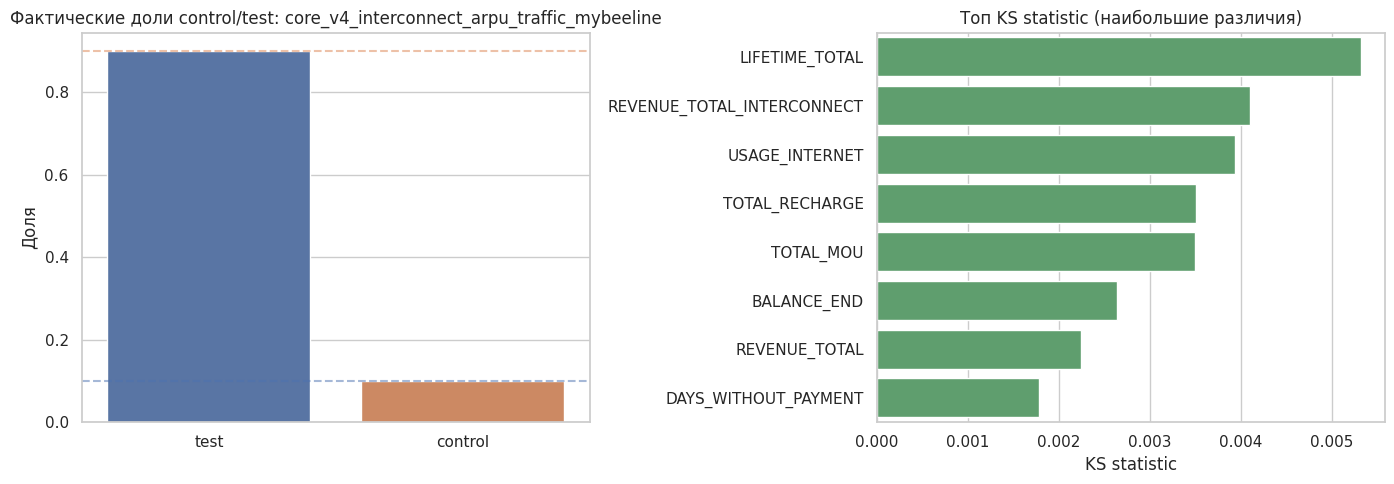

## Что получилось после split

,metric,value
0,split_version,core_v4_interconnect_arpu_traffic_mybeeline
1,control_share_fact,0.10000
2,test_share_fact,0.90000
3,srm_p_value,0.99953
4,ks_features_checked,8
5,ks_significant_after_fdr,0
6,max_strata_abs_deviation,0.10000
7,n_core_strata_features,10
8,n_selected_strata_features,10


Assignment сохранен: /data/aturov/universal_control_group/data/processed/ukg_assignment_2026-02-01.parquet


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=group_summary, x="group", y="share", hue="group", dodge=False, palette=["#4C72B0", "#DD8452"], ax=axes[0])
axes[0].axhline(CONTROL_SHARE, linestyle="--", color="#4C72B0", alpha=0.5)
axes[0].axhline(1 - CONTROL_SHARE, linestyle="--", color="#DD8452", alpha=0.5)
axes[0].set_title(f"Фактические доли control/test: {selected_split_version}")
axes[0].set_xlabel("")
axes[0].set_ylabel("Доля")

if "ks_report" in globals() and not ks_report.empty:
    plot_ks = ks_report.sort_values("ks_stat", ascending=False).head(10).copy()
    sns.barplot(data=plot_ks, x="ks_stat", y="feature", color="#55A868", ax=axes[1])
    axes[1].set_title("Топ KS statistic (наибольшие различия)")
    axes[1].set_xlabel("KS statistic")
    axes[1].set_ylabel("")
else:
    axes[1].text(0.5, 0.5, "Нет данных для KS-графика", ha="center", va="center")
    axes[1].set_title("KS визуализация")

plt.tight_layout()
plt.show()

result_summary = pd.DataFrame(
    {
        "metric": [
            "split_version",
            "control_share_fact",
            "test_share_fact",
            "srm_p_value",
            "ks_features_checked",
            "ks_significant_after_fdr",
            "max_strata_abs_deviation",
            "n_core_strata_features",
            "n_selected_strata_features",
        ],
        "value": [
            selected_split_version,
            float(srm["control_share"]),
            float(srm["test_share"]),
            float(srm["p_value"]),
            int(len(ks_report)) if "ks_report" in globals() else 0,
            int(ks_report["ks_significant_0_05"].sum()) if "ks_report" in globals() and not ks_report.empty else 0,
            float((strata_quality["control_share"] - CONTROL_SHARE).abs().max()),
            int(len(strata_cols)),
            int(len(selected_strata_cols)),
        ],
    }
)

display(Markdown("## Что получилось после split"))
display(result_summary)

export_cols = [col for col in ["SUBS_ID", "experiment_group", "split_hash", "strata_key"] if col in assignment_df.columns]
assignment_path = path_config.data_processed_path / f"ukg_assignment_{DATA_START}.parquet"
assignment_df[export_cols].to_parquet(assignment_path, index=False)
print(f"Assignment сохранен: {assignment_path}")

## Выводы

Ключевые выводы split-ноутбука:
- разбиение на `control/test` построено детерминированно и воспроизводимо
- фактическая доля `control` близка к целевой
- по KS (с FDR-коррекцией) значимых различий по выбранным numeric-колонкам не обнаружено

In [7]:
split_conclusion = pd.DataFrame(
    {
        "metric": [
            "rows_assigned",
            "control_share_fact",
            "test_share_fact",
            "srm_p_value",
            "ks_features_checked",
            "ks_significant_after_fdr",
            "max_strata_abs_deviation",
        ],
        "value": [
            len(assignment_df),
            float(srm["control_share"]),
            float(srm["test_share"]),
            float(srm["p_value"]),
            int(len(ks_report)),
            int(ks_report["ks_significant_0_05"].sum()) if not ks_report.empty else 0,
            float((strata_quality["control_share"] - CONTROL_SHARE).abs().max()),
        ],
    }
)

display(Markdown("### Итоговая сводка split"))
display(split_conclusion)

if float(srm["p_value"]) >= 0.05 and (ks_report.empty or int(ks_report["ks_significant_0_05"].sum()) == 0):
    print("Итог: split корректный, признаков системного дисбаланса не выявлено.")
else:
    print("Итог: есть сигналы дисбаланса, требуется корректировка split-политики.")

### Итоговая сводка split

,metric,value
0,rows_assigned,"2,921,367.00000"
1,control_share_fact,0.10000
2,test_share_fact,0.90000
3,srm_p_value,0.99953
4,ks_features_checked,7.00000
5,ks_significant_after_fdr,0.00000
6,max_strata_abs_deviation,0.10000


Итог: split корректный, признаков системного дисбаланса не выявлено.
